# A tour of the STARfinder readout module

This notebook introduces the §2.8 readout module of the maintained Python package: intensity
extraction, barcode decoding and direct assignment, the local background, the shared read-QC
score, optional deduplication, read filtering, checkpoints and diagnostics. The code lives in
`starfinder.barcode`, `FOV.run` in `starfinder.dataset` runs it, and its metrics are in
`starfinder.evaluation.barcode`. Like the §2.6 and §2.7 tours
(`starfinder_registration_tour.ipynb`, `starfinder_spot_finding_tour.ipynb`), it runs every
piece through the public API, on small synthetic fixtures whose answers are known:

1. the architecture of the stage;
2. encodings and the four worked examples;
3. the segment layout and the `split_index` key;
4. a multiplexed run on a calibrated scene;
5. a direct-readout run;
6. background and noise;
7. the shared score;
8. deduplication;
9. filtering and the defaults;
10. checkpoints and reruns without images;
11. the three diagnostics;
12. checks and limits;
13. clean up.

Every section first explains a design choice and then runs the code that shows it. The design
is specified in three pages accepted at W-280 (section 1). The notebook links those pages
rather than repeating them. **It is not a benchmark.** It compares no methods, chooses no
default and draws no score cutoff. The only ranking numbers it shows are on one calibrated
scene: the shared score against the decoder's own score (section 7), next to the W-278
measurements behind the design. Every array is at most 32×64×64 voxels, with four channels and
four rounds (section 12 checks it). Everything runs on one CPU thread, without a GPU and without a learned detector.

The setup cell draws figures inline. It keeps the numerical libraries on one thread (set before
NumPy is imported) and hides any GPU. It checks that `starfinder` is imported from the checkout
that holds this notebook. It also checks that no learned-detector backend (torch, Spotiflow,
Piscis) is imported: the readout module does not need one, and the notebook detects with local
maxima only. Everything the notebook writes goes to a new temporary workspace, which section 13
removes. Four helpers are defined here:

* `clean` writes that workspace as `<workspace>`, so no machine-specific path is printed;
* `error_of` prints the error a call raises;
* `timed` records the wall time of the slower steps for section 12;
* `note` records the shape and axes of every array that the notebook's own code allocates, and
  `keep` does so for the round images of a fixture, for the size audit of section 12.

In [1]:
%matplotlib inline
import os

for variable in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS",
                 "NUMBA_NUM_THREADS"):
    os.environ.setdefault(variable, "1")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "")

import sys
import hashlib
import json
import tempfile
import time
import weakref
from contextlib import contextmanager
from dataclasses import fields, replace
from pathlib import Path
from types import MappingProxyType

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import starfinder
import starfinder.barcode
import starfinder.dataset
import starfinder.evaluation.barcode
import starfinder.spot_finding
import starfinder.synthetic

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 80)

REPOSITORY = Path(starfinder.__file__).resolve().parents[3]
print("starfinder imported from:", Path(starfinder.__file__).resolve().relative_to(REPOSITORY).as_posix())
print("the same checkout as this notebook:", Path.cwd().resolve().is_relative_to(REPOSITORY))
print("learned-detector backends imported:", {name: name in sys.modules for name in ("torch", "spotiflow", "piscis")})
print("threads:", {v: os.environ[v] for v in ("OMP_NUM_THREADS", "NUMBA_NUM_THREADS")},
      " CUDA_VISIBLE_DEVICES:", repr(os.environ["CUDA_VISIBLE_DEVICES"]))

_workspace = tempfile.TemporaryDirectory(prefix="starfinder-readout-tour-")
WORKSPACE = Path(_workspace.name)
TIMINGS = {}
ARRAYS = {}
NOTED = {}
ROUND_COUNTS = {}
CHANNELS = ("ch00", "ch01", "ch02", "ch03")


def clean(text):
    # Write the temporary workspace as <workspace>.
    return str(text).replace(str(WORKSPACE), "<workspace>")


def show(obj):
    print(clean(obj if isinstance(obj, str) else repr(obj)))


def error_of(call):
    # Run call, which must raise; return "<error type>: <message>" with clean paths.
    try:
        call()
    except Exception as error:
        return clean(f"{type(error).__name__}: {error}")
    raise AssertionError("expected an error")


@contextmanager
def timed(label):
    start = time.perf_counter()
    yield
    TIMINGS[label] = time.perf_counter() - start


def note(name, array, axes):
    # Record the shape and axes of an array the notebook allocates; return the array unchanged.
    assert array.ndim == len(axes), (name, array.shape, axes)
    ARRAYS.setdefault((name, axes), set()).add(array.shape)
    NOTED[id(array)] = weakref.ref(array)
    return array


def keep(name, images):
    # Record each ZYXC round image of a fixture and the number of rounds; return the images unchanged.
    for image in images.values():
        note(f"{name} round image", image, ("z", "y", "x", "channel"))
    ROUND_COUNTS[name] = len(images)
    return images


def rounds(n):
    return tuple(f"round{i}" for i in range(1, n + 1))


print("workspace: a new temporary directory, removed at the end")

starfinder imported from: src/python/starfinder/__init__.py
the same checkout as this notebook: True
learned-detector backends imported: {'torch': False, 'spotiflow': False, 'piscis': False}
threads: {'OMP_NUM_THREADS': '1', 'NUMBA_NUM_THREADS': '1'}  CUDA_VISIBLE_DEVICES: ''
workspace: a new temporary directory, removed at the end


## 1. Architecture of the stage

**Terms.** The readout design uses a few words with fixed meanings
([docs/readout-contract.md](../../docs/readout-contract.md), "Terms"):

* a **candidate** is one row of the spot table that spot finding returns;
* a **read** is the readout of one candidate: one row of the read table;
* the **readout mode** says how a read gets its identity. In `multiplexed` mode it comes from a
  color sequence over all sequencing rounds, matched against a codebook. In `direct` mode it
  comes from the candidate's own round and channel, looked up in a panel;
* an **encoding** maps a barcode's bases to a color sequence and back;
* a **segment layout** describes how one barcode is cut into separately read segments, and in
  which order their colors are acquired;
* a **codebook entry** is one barcode with its color sequence (`entry_id`). A **gene** is what
  the entry measures (`gene_id`), and several entries may share a gene;
* a **call** is a read's identity decision (`call_status`, `call_type`). The **score** ranks
  calls and never changes them.

**The stage.** `FOV.run` runs, after detection: extract → decode (`multiplexed`) or assign
(`direct`) → score → deduplicate → filter. Each stage is optional. Each stage reads only the
results the earlier stages retained, so a stage can be rerun from a checkpoint without images
(section 10). Each stage is a public function with a frozen config and a result object, and the
FOV keeps every result. The readout mode is a dataset setting (`Dataset.readout_mode`), like the
codebook and the panel that the dataset holds. The cell prints the stages with their configs,
functions, results and FOV attributes, and the readout settings of `Dataset` and
`PipelineConfig`.

In [2]:
from starfinder.barcode import (BarcodeDecodingResult, CodebookAwareDecoderConfig, DeduplicationConfig,
                                DirectAssignmentConfig, IntensityExtractionResult, NeighborhoodSumConfig,
                                ReadDeduplicationResult, ReadFilterConfig, ReadFilteringResult, ReadScoreConfig,
                                ReadScoringResult, WtaDecoderConfig, assign_direct, decode_barcodes,
                                deduplicate_reads, extract_intensities, filter_reads, score_reads)
from starfinder.dataset import CheckpointConfig, Dataset, PipelineConfig, RoundState

stages = pd.DataFrame([
    dict(stage="extract", config="NeighborhoodSumConfig", function=extract_intensities.__name__,
         result=IntensityExtractionResult.__name__, fov_attribute="intensity_result", pipeline_field="extraction"),
    dict(stage="decode (multiplexed)", config="WtaDecoderConfig, CodebookAwareDecoderConfig",
         function=decode_barcodes.__name__, result=BarcodeDecodingResult.__name__, fov_attribute="decoding_result",
         pipeline_field="decoding"),
    dict(stage="assign (direct)", config="DirectAssignmentConfig", function=assign_direct.__name__,
         result=BarcodeDecodingResult.__name__, fov_attribute="decoding_result", pipeline_field="decoding"),
    dict(stage="score", config="ReadScoreConfig", function=score_reads.__name__, result=ReadScoringResult.__name__,
         fov_attribute="scoring_result", pipeline_field="scoring"),
    dict(stage="deduplicate", config="DeduplicationConfig", function=deduplicate_reads.__name__,
         result=ReadDeduplicationResult.__name__, fov_attribute="deduplication_result", pipeline_field="deduplication"),
    dict(stage="filter", config="ReadFilterConfig", function=filter_reads.__name__,
         result=ReadFilteringResult.__name__, fov_attribute="filtering_result", pipeline_field="filtering"),
])
display(stages)
print("Dataset.readout_mode default:", repr(next(f for f in fields(Dataset) if f.name == "readout_mode").default))
print("PipelineConfig readout fields (Python defaults):",
      {f.name: getattr(PipelineConfig(), f.name) for f in fields(PipelineConfig)
       if f.name in ("extraction", "decoding", "scoring", "deduplication", "filtering")})

,stage,config,function,result,fov_attribute,pipeline_field
0,extract,NeighborhoodSumConfig,extract_intensities,IntensityExtractionResult,intensity_result,extraction
1,decode (multiplexed),"WtaDecoderConfig, CodebookAwareDecoderConfig",decode_barcodes,BarcodeDecodingResult,decoding_result,decoding
2,assign (direct),DirectAssignmentConfig,assign_direct,BarcodeDecodingResult,decoding_result,decoding
3,score,ReadScoreConfig,score_reads,ReadScoringResult,scoring_result,scoring
4,deduplicate,DeduplicationConfig,deduplicate_reads,ReadDeduplicationResult,deduplication_result,deduplication
5,filter,ReadFilterConfig,filter_reads,ReadFilteringResult,filtering_result,filtering


Dataset.readout_mode default: 'multiplexed'
PipelineConfig readout fields (Python defaults): {'extraction': None, 'decoding': None, 'filtering': None, 'scoring': None, 'deduplication': None}


**Where the accepted pages live.** The design is in three pages, accepted at W-280 on
2026-10-02. The cell prints their titles and status lines from the files:

* [docs/readout-baseline.md](../../docs/readout-baseline.md) records the behavior before §2.8,
  with the golden test;
* [docs/readout-contract.md](../../docs/readout-contract.md) holds the readout modes, the
  registries, the segment layout, entries, direct readout, extraction and background, the score,
  deduplication, the runtime order and defaults, checkpoints, diagnostics and workflow keys;
* [docs/readout-algorithms.md](../../docs/readout-algorithms.md) holds the numerical rules, the
  worked examples, the engineering validation design (checks R1 to R19) and its implementation.

The registry rules shared by all stages are in [docs/method-registry.md](../../docs/method-registry.md).

In [3]:
for page in ("readout-baseline", "readout-contract", "readout-algorithms"):
    lines = (REPOSITORY / "docs" / f"{page}.md").read_text().splitlines()
    status = next(line for line in lines if line.startswith("Status:"))
    print(f"docs/{page}.md: {lines[0].lstrip('# ')}\n    {status}")

docs/readout-baseline.md: Readout baseline: extraction, decoding and read QC
    Status: Accepted (W-280, 2026-10-02, at b1c7261)
docs/readout-contract.md: Readout contract: extraction, decoding and read QC
    Status: Accepted (W-280, 2026-10-02, at b1c7261)
docs/readout-algorithms.md: Readout algorithm specification
    Status: Accepted (W-280, 2026-10-02, at b1c7261)


**The registries.** Decoders and encodings are registered as the other stages' methods are
([docs/method-registry.md](../../docs/method-registry.md)). A registry is a plain dictionary
from each exact config type to a frozen spec that declares the method's name and capabilities.
Everything that needs the set of decoders or encodings derives it from the registry:
`decode_barcodes`, `assign_direct`, `PipelineConfig.decoding`, `FOV.run`, the workflow adapter
and the checkpoint reader. `DECODING_METHODS` declares for each decoder:

* `modes`: the readout modes it supports;
* `encodings`: the encoding symbol kinds it decodes;
* `rescue`: whether it can change an observed color;
* `score_columns`: the numeric columns it writes, which `filter_reads` may bound.

`ENCODINGS` declares for each encoding the number of colors of an n-base segment, whether
decoding needs the segment's first base, the junction colors between two segments, and the
color alphabet. Both color decoders declare the symbol kind `color`. They read one color per
round and nothing else from the encoding, so they decode `two_base` and `one_base` codebooks
unchanged.

In [4]:
from starfinder.barcode import DECODING_METHODS, ENCODINGS

decoders = pd.DataFrame([dict(
    name=spec.name, config=config_type.__name__, modes=", ".join(sorted(spec.modes)),
    encodings=", ".join(sorted(spec.encodings)) or "none", rescue=spec.rescue,
    score_columns=", ".join(spec.score_columns) or "none",
) for config_type, spec in DECODING_METHODS.items()])
encodings = pd.DataFrame([dict(
    name=spec.name, config=config_type.__name__, colors_for_n_bases="n - 1" if spec.colors_for(6) == 5 else "n",
    needs_first_base=spec.needs_first_base, junction_colors=spec.junction_colors, alphabet=spec.alphabet,
    symbols=spec.symbols,
) for config_type, spec in ENCODINGS.items()])
display(decoders)
display(encodings)

,name,config,modes,encodings,rescue,score_columns
0,wta,WtaDecoderConfig,multiplexed,color,False,wta_l2_nll
1,codebook_aware,CodebookAwareDecoderConfig,multiplexed,color,True,"probability_nll, score_delta, geomean_probability, min_round_margin, correct..."
2,direct,DirectAssignmentConfig,direct,none,False,"own_channel_rank, own_channel_fraction"


,name,config,colors_for_n_bases,needs_first_base,junction_colors,alphabet,symbols
0,two_base,EncodingConfig,n - 1,True,1,1234,color
1,one_base,OneBaseEncodingConfig,n,False,0,1234,color


## 2. Encodings and the four worked examples

`two_base` is the existing STARmap encoding. Each pair of adjacent bases gives one color
(`encode_bases`), after the bases are reversed when `reverse_bases` is true, so an n-base
barcode gives n − 1 colors. Decoding back needs the segment's first base in read orientation
(`decode_color_sequence(colors, first_base)`). `one_base` gives one color per base through an
explicit mapping `base_to_color`, which has no default.

The `two_base` pair-to-color table is a parameter: `EncodingConfig.pair_to_color` maps the 16
ordered base pairs to the colors 1 to 4. Its default is the table of `src/matlab/EncodeBases.m`
(above), and a table may relabel the colors or pair the bases differently, as long as the four
pairs that start with one base have four different colors (else decoding from that base would be
ambiguous). `Dataset.encoding_table()` (or `Codebook.encoding_table()`) shows the table of the
loaded codebook with the channel of each color, the summary of the dataset and of the codebook
names the encoding and the segment layout, and `pre_qc.json` and `run.json` record the encoding
(amendment W-304 of [docs/readout-contract.md](../../docs/readout-contract.md), "Encoding
registry").

[docs/readout-algorithms.md](../../docs/readout-algorithms.md), "Worked examples", gives one
example for each encoding and layout and one for direct readout, and
`test_readout_examples.py` checks each of them step by step. The cells below follow the same
steps through the public functions and print every value.

Examples 1 and 2 have 5 and 9 rounds. The notebook builds no intensity array with more than four
rounds, so for them it shows the encoding, the codebook loaded through `Dataset.load_codebook`,
and the codebook lookup of the color sequence: a read matches an entry on its whole color
sequence. Example 3 has 4 rounds, so the helper `clean_read` also builds the extraction result of
one clean read and decodes it with WTA. The read's brightest channel in each round is the given
color: 100 in that channel and 1 in the others.

In [5]:
from starfinder.barcode import (Codebook, EncodingConfig, OneBaseEncodingConfig, decode_color_sequence, encode_bases,
                                load_codebook)
from starfinder.image import ImageMetadata


def clean_read(book, colors):
    # The WTA call of one read whose brightest channel in each round is the given color (at most four rounds).
    if len(colors) > 4 or len(book.channel_labels) > 4:
        raise ValueError("the notebook builds intensity arrays of at most four rounds and four channels")
    values = note("clean_read sums", np.full((1, len(book.channel_labels), len(colors)), 1.0),
                  ("spot", "channel", "round"))
    for r, color in enumerate(colors):
        values[0, book.color_to_channel[color], r] = 100.0
    valid = note("clean_read valid", np.ones((1, len(colors)), bool), ("spot", "round"))
    read = IntensityExtractionResult(values, ("read",), "tour/examples", book.channel_labels, book.round_labels,
                                     ImageMetadata("tour/examples"), NeighborhoodSumConfig(), valid, {})
    return decode_barcodes(read, book, config=WtaDecoderConfig()).table.iloc[0]


def codebook_of(name, n_rounds, rows, **options):
    # The codebook of a gene,barcode file loaded through Dataset.load_codebook for n_rounds sequencing rounds.
    root = WORKSPACE / name
    root.mkdir()
    dataset = Dataset(root, root / "out", name, "sample", "out",
                      rounds=RoundState(sequencing_rounds=list(rounds(n_rounds)), reference_round="round1"),
                      channel_order=list(CHANNELS))
    dataset.load_codebook(genes_csv(f"{name}.csv", rows), **options)
    return dataset.codebook


def genes_csv(name, rows):
    # A headerless gene,barcode codebook file in the workspace.
    path = WORKSPACE / name
    path.write_text("".join(f"{gene},{barcode}\n" for gene, barcode in rows))
    return path


# Example 1: two_base, one segment.
barcode = "CTGACC"
reversed_bases = barcode[::-1]
pairs = [reversed_bases[i:i + 2] for i in range(len(reversed_bases) - 1)]
colors = EncodingConfig(reverse_bases=True).encode(barcode)
print(f"Example 1. Slc17a7, barcode {barcode}, 5 rounds")
print(f"  reversed {reversed_bases}; pairs {', '.join(pairs)} -> colors {[encode_bases(p) for p in pairs]}")
print(f"  EncodingConfig(reverse_bases=True).encode({barcode!r}) = {colors}")
book = codebook_of("example1", 5, [("Slc17a7", barcode)])
display(book.table)
print(f"  observed {colors} matches entry {book.seq_to_entry[colors]} -> gene {book.seq_to_gene[colors]}")
back = decode_color_sequence(colors, "C")
print(f"  back: decoded from the first base C: {back}; reversed: {back[::-1]}")
print(f"  end bases in read orientation: {back[0] + back[-1]}")

Example 1. Slc17a7, barcode CTGACC, 5 rounds
  reversed CCAGTC; pairs CC, CA, AG, GT, TC -> colors ['1', '2', '3', '2', '3']
  EncodingConfig(reverse_bases=True).encode('CTGACC') = 12323


,entry_id,gene_id,base_sequence,color_sequence
0,CTGACC,Slc17a7,CTGACC,12323


  observed 12323 matches entry CTGACC -> gene Slc17a7
  back: decoded from the first base C: CCAGTC; reversed: CTGACC
  end bases in read orientation: CC


In [6]:
# Example 2: two_base, two segments (the aging shape, 11 bases read as 5 + 4 colors over 9 rounds).
segment_a, segment_b = "CAGTAC", "TGCAT"
barcode = segment_a + segment_b
all_colors = encode_bases(barcode[::-1])
print(f"Example 2. Gfap_probe1, barcode {barcode} = segment A {segment_a} + segment B {segment_b}, 9 rounds")
print(f"  reversed {barcode[::-1]}; encoded {all_colors} (c1 to c10)")
print(f"  c5 = {all_colors[4]} is the pair {barcode[::-1][4:6]} across the junction (first base of B, last base "
      f"of A): dropped")
print(f"  segment A {segment_a[::-1]} (read orientation) -> {all_colors[5:]} (rounds 1-5); "
      f"segment B {segment_b[::-1]} -> {all_colors[:4]} (rounds 6-9)")
two_segments = EncodingConfig(reverse_bases=True, split_index=4)
colors = two_segments.encode(barcode)
print(f"  EncodingConfig(reverse_bases=True, split_index=4).encode({barcode!r}) = {colors}")
book = codebook_of("example2", 9, [("Gfap_probe1", barcode)], encoding=two_segments)
print(f"  observed {colors} matches entry {book.seq_to_entry[colors]} -> gene {book.seq_to_gene[colors]}")
first, second = colors[:5], colors[5:]
a, b = decode_color_sequence(first, "C"), decode_color_sequence(second, "T")
print(f"  back: cut {first} | {second}; A from C: {a}, reversed {a[::-1]}; B from T: {b}, reversed {b[::-1]}; "
      f"joined {a[::-1] + b[::-1]}")
print(f"  end bases in read orientation: A {a[0] + a[-1]}, B {b[0] + b[-1]}")

Example 2. Gfap_probe1, barcode CAGTACTGCAT = segment A CAGTAC + segment B TGCAT, 9 rounds
  reversed TACGTCATGAC; encoded 4242324232 (c1 to c10)
  c5 = 3 is the pair TC across the junction (first base of B, last base of A): dropped
  segment A CATGAC (read orientation) -> 24232 (rounds 1-5); segment B TACGT -> 4242 (rounds 6-9)
  EncodingConfig(reverse_bases=True, split_index=4).encode('CAGTACTGCAT') = 242324242
  observed 242324242 matches entry CAGTACTGCAT -> gene Gfap_probe1
  back: cut 24232 | 4242; A from C: CATGAC, reversed CAGTAC; B from T: TACGT, reversed TGCAT; joined CAGTACTGCAT
  end bases in read orientation: A CC, B TT


In [7]:
# Example 3: one_base.
ONE_BASE = OneBaseEncodingConfig({"A": "1", "C": "2", "G": "3", "T": "4"})
one_base = ENCODINGS[OneBaseEncodingConfig]
barcode = "GATC"
colors = one_base.encode(barcode, ONE_BASE)
print(f"Example 3. Mbp, barcode {barcode}, mapping {ONE_BASE.base_to_color}, reverse_bases={ONE_BASE.reverse_bases}")
print(f"  one_base encode: {colors}; decode back: {one_base.decode(colors, ONE_BASE, None)}")
book = load_codebook(genes_csv("example3.csv", [("Mbp", barcode)]), round_labels=rounds(4), channel_labels=CHANNELS,
                     encoding=ONE_BASE)
display(book.table)
read = clean_read(book, colors)
print(f"  observed {read.observed_color_sequence} -> {read.gene_id}, {read.call_status} ({read.call_type})")
print(f"  the two_base encoding of the same 4 bases has {len(EncodingConfig(reverse_bases=False).encode(barcode))} "
      f"colors: {EncodingConfig(reverse_bases=False).encode(barcode)}")

Example 3. Mbp, barcode GATC, mapping {'A': '1', 'C': '2', 'G': '3', 'T': '4'}, reverse_bases=False
  one_base encode: 3142; decode back: GATC


,entry_id,gene_id,base_sequence,color_sequence
0,GATC,Mbp,GATC,3142


  observed 3142 -> Mbp, assigned (exact)
  the two_base encoding of the same 4 bases has 3 colors: 343


**The encoding table.** The next cell loads the example 1 codebook into a dataset and prints its
summary and its table through `Dataset.encoding_table()`, as a grid of first base × second base
(read orientation), with the channel of each color. It then loads the same file with the second
table kept as comments in `EncodeBases.m` (the default with the colors relabelled 1 → 3, 2 → 2,
3 → 4, 4 → 1): the barcode gets other colors and the summary says the table is not the default.
A table in which one first base gives two pairs the same color raises.

In [8]:
# The encoding table through the public calls.
RELABELLED_PAIRS = {"AT": "1", "TA": "1", "GC": "1", "CG": "1", "AC": "2", "CA": "2", "GT": "2", "TG": "2",
                    "AA": "3", "TT": "3", "GG": "3", "CC": "3", "AG": "4", "GA": "4", "CT": "4", "TC": "4"}


def color_grid(table):
    # The 16 pairs of a two_base encoding table as a first base x second base grid of colors.
    return (table.assign(first=table.bases.str[0], second=table.bases.str[1])
            .pivot(index="first", columns="second", values="color"))


table_root = WORKSPACE / "encoding-table"
table_root.mkdir()
table_dataset = Dataset(table_root, table_root / "out", "encoding-table", "sample", "out",
                        rounds=RoundState(sequencing_rounds=list(rounds(5)), reference_round="round1"),
                        channel_order=list(CHANNELS))
table_csv = genes_csv("encoding-table.csv", [("Slc17a7", "CTGACC")])
table_dataset.load_codebook(table_csv)
show(table_dataset)
default_table = table_dataset.encoding_table()
print(f"Dataset.encoding_table(): {len(default_table)} rows, columns {list(default_table.columns)}")
display(color_grid(default_table))
print("color -> channel:", dict(default_table[["color", "channel"]].drop_duplicates().sort_values("color").values))
print("default color sequence of Slc17a7 CTGACC:", table_dataset.codebook.table.color_sequence[0])

table_dataset.load_codebook(table_csv, encoding=EncodingConfig(pair_to_color=RELABELLED_PAIRS))
print()
print(table_dataset.codebook)
relabelled_table = table_dataset.encoding_table()
display(color_grid(relabelled_table))
print("relabelled color sequence of Slc17a7 CTGACC:", table_dataset.codebook.table.color_sequence[0])
print("the same table through the codebook and the FOV:",
      relabelled_table.equals(table_dataset.codebook.encoding_table())
      and relabelled_table.equals(table_dataset.fov("FOV_001").encoding_table()))
print("one_base table:", dict(load_codebook(genes_csv("encoding-table-one-base.csv", [("Mbp", "GATC")]),
                                            round_labels=rounds(4), channel_labels=CHANNELS,
                                            encoding=ONE_BASE).encoding_table()[["bases", "color"]].values))
print("an invalid table:", error_of(lambda: EncodingConfig(pair_to_color={**RELABELLED_PAIRS, "CC": "1"})))

Dataset 'encoding-table' (sample 'sample', output 'out')
    sequencing rounds: round1*, round2, round3, round4, round5   (* reference)
    other rounds:      none
    channels:          ch00, ch01, ch02, ch03
    codebook:          1 genes × 5 rounds
    encoding:          two_base, one segment of 5 colors
    input root:        <workspace>/encoding-table
    output root:       <workspace>/encoding-table/out
Dataset.encoding_table(): 16 rows, columns ['bases', 'color', 'channel']


second,A,C,G,T
first,,,,
A,1,2,3,4
C,2,1,4,3
G,3,4,1,2
T,4,3,2,1


color -> channel: {'1': 'ch00', '2': 'ch01', '3': 'ch02', '4': 'ch03'}
default color sequence of Slc17a7 CTGACC: 12323

Codebook: 1 genes × 5 rounds, channels ch00, ch01, ch02, ch03; encoding two_base, one segment of 5 colors, non-default pair_to_color table


second,A,C,G,T
first,,,,
A,3,2,4,1
C,2,3,1,4
G,4,1,3,2
T,1,4,2,3


relabelled color sequence of Slc17a7 CTGACC: 32424
the same table through the codebook and the FOV: True
one_base table: {'A': '1', 'C': '2', 'G': '3', 'T': '4'}
an invalid table: ValueError: pair_to_color must give the four pairs that start with C four different colors (else decoding from C is ambiguous); got CA 2, CC 1, CG 1, CT 4


**Example 4, direct readout.** In a direct-readout assay each (round, channel) of a panel stains
one gene. The `direct2` fixture is the worked example: two rounds of 6×24×24 voxels, background
100 with noise sd 3 (seed 100), and four spots planted as Gaussians of amplitude 1000 and sd 1
voxel, each in its own round and channel. The first and the last spot share the position
(3, 8, 8) in different rounds. The cell builds the fixture as `test_readout_examples.py` does. It
loads the panel with `load_direct_panel`, which rejects a gene that appears twice, and detects in
both rounds with a plan that lists them (option A of the §2.7 multi-round candidate set). Then
it extracts each candidate in its own round and assigns the panel gene. Section 5 runs the same
fixture through `FOV.run`.

In [9]:
from starfinder.barcode import DirectPanel, load_direct_panel
from starfinder.spot_finding import LocalMaximaConfig, SpotFindingPlan, SpotFindingResult

DIRECT_ROUNDS = rounds(2)
DIRECT_MAPPING = pd.DataFrame({"round": ["round1"] * 4 + ["round2"] * 4, "channel": list(CHANNELS) * 2,
                               "gene_id": ["Gfap", "Slc17a7", "Gad1", "Mbp", "Pvalb", "Sst", "Vip", "Aqp4"]})
# (round, channel index, z, y, x) of the planted spots.
DIRECT_SPOTS = [("round1", 0, 3, 8, 8), ("round1", 2, 3, 16, 16), ("round2", 1, 3, 8, 16), ("round2", 3, 3, 8, 8)]
DIRECT_PLAN = SpotFindingPlan(LocalMaximaConfig("noise", 10.0), rounds=DIRECT_ROUNDS)
DIRECT_METADATA = ImageMetadata("example/FOV_001")


def direct_images(seed=100):
    # Two uint16 ZYXC rounds of 6x24x24: background 100, noise sd 3, a Gaussian of 1000 and sd 1 per planted spot.
    shape = (6, 24, 24)
    rng = np.random.RandomState(seed)
    z, y, x = (note("direct2 grid", g, ("z", "y", "x"))
               for g in np.meshgrid(*(np.arange(n, dtype=np.float64) for n in shape), indexing="ij"))
    images = {name: note("direct2 float image", 100 + rng.normal(0, 3, shape + (4,)), ("z", "y", "x", "channel"))
              for name in DIRECT_ROUNDS}
    for name, channel, cz, cy, cx in DIRECT_SPOTS:
        spot = note("direct2 spot", 1000 * np.exp(-((z - cz) ** 2 + (y - cy) ** 2 + (x - cx) ** 2) / 2),
                    ("z", "y", "x"))
        images[name][..., channel] += spot
    return keep("direct2", {name: np.rint(image).astype(np.uint16) for name, image in images.items()})


def direct_dataset(root, panel=DIRECT_MAPPING):
    root.mkdir(parents=True, exist_ok=True)
    dataset = Dataset(root, root / "out", "example", "sample", "out",
                      rounds=RoundState(sequencing_rounds=list(DIRECT_ROUNDS), reference_round="round1"),
                      channel_order=list(CHANNELS), readout_mode="direct")
    panel.to_csv(root / "panel.csv", index=False)
    dataset.load_direct_panel(root / "panel.csv")
    return dataset


def direct_fov(dataset):
    fov = dataset.fov("FOV_001")
    fov.images = direct_images()
    fov.metadata = {name: DIRECT_METADATA for name in DIRECT_ROUNDS}
    return fov


print("Example 4. Direct readout, two rounds. The panel:")
display(DIRECT_MAPPING.pivot(index="round", columns="channel", values="gene_id"))
invalid = DIRECT_MAPPING.replace({"gene_id": {"Vip": "Gfap"}})
invalid.to_csv(WORKSPACE / "invalid-panel.csv", index=False)
print("  Vip replaced by Gfap:", error_of(lambda: load_direct_panel(WORKSPACE / "invalid-panel.csv",
                                                                     round_labels=DIRECT_ROUNDS,
                                                                     channel_labels=CHANNELS)))
fov = direct_fov(direct_dataset(WORKSPACE / "example4"))
fov.find_spots(config=DIRECT_PLAN).extract_intensities().decode_barcodes(config=DirectAssignmentConfig())
example4 = fov.decoding_result.table
print("  candidates (round, channel, z, y, x):",
      list(zip(fov.spot_result.spots["round"], fov.spot_result.spots.channel,
               *(fov.spot_result.spots[a].astype(int) for a in "zyx"))))
print("  genes:", example4.gene_id.tolist())

Example 4. Direct readout, two rounds. The panel:


channel,ch00,ch01,ch02,ch03
round,,,,
round1,Gfap,Slc17a7,Gad1,Mbp
round2,Pvalb,Sst,Vip,Aqp4


  Vip replaced by Gfap: ValueError: <workspace>/invalid-panel.csv: rows 2 and 8: gene 'Gfap' appears more than once


  candidates (round, channel, z, y, x): [('round1', 0, 3, 8, 8), ('round1', 2, 3, 16, 16), ('round2', 1, 3, 8, 16), ('round2', 3, 3, 8, 8)]
  genes: ['Gfap', 'Gad1', 'Sst', 'Aqp4']


## 3. The segment layout and the `split_index` key

A segment layout is a typed description on the codebook, not a registry
([docs/readout-contract.md](../../docs/readout-contract.md), "Segment layout"). `Segment(name,
bases, ends)` gives a segment's length in bases and its allowed (first, last) bases in read
orientation. `BarcodeLayout(segments, acquisition_order)` lists the segments in barcode order
and the order in which their colors are acquired. Each segment is encoded on its own bases. The
`two_base` color that spans two segments (the junction) is never acquired, never decoded and
never compared. A read matches an entry on the whole concatenated color sequence, as in MATLAB.
The end-base check runs per segment and is diagnostic; it rejects reads only when the filter
asks for it. An entry whose segment ends are not among the allowed ones raises when the
codebook loads.

The first cell writes example 2 as a layout, A = 6 bases (5 colors, rounds 1–5) and B = 5 bases
(4 colors, rounds 6–9), with ends `CC` and `TT`. The codebook is the same as with the legacy
zero-based `EncodingConfig(split_index=4)`, but the layout codebook also carries the allowed
ends. An entry whose segment B ends in `TA` then raises.

In [10]:
from starfinder.barcode import BarcodeLayout, Segment

LAYOUT = BarcodeLayout((Segment("A", 6, (("C", "C"),)), Segment("B", 5, (("T", "T"),))), ("A", "B"))
path = genes_csv("example2.csv", [("Gfap_probe1", "CAGTACTGCAT")])
by_layout = load_codebook(path, round_labels=rounds(9), channel_labels=CHANNELS, layout=LAYOUT)
by_split = load_codebook(path, round_labels=rounds(9), channel_labels=CHANNELS,
                         encoding=EncodingConfig(split_index=4))
show(LAYOUT)
print("by layout:  ", by_layout.table[["entry_id", "gene_id", "color_sequence"]].to_dict("records"))
print("by split_index=4:", by_split.table[["entry_id", "gene_id", "color_sequence"]].to_dict("records"))
print("the legacy split as a layout:", by_split.layout)
wrong_end = genes_csv("wrong-end.csv", [("Gfap_probe1", "CAGTACTGCAT"), ("Bad", "CAGTACAGCAA")])
print(error_of(lambda: load_codebook(wrong_end, round_labels=rounds(9), channel_labels=CHANNELS, layout=LAYOUT)))

BarcodeLayout(segments=(Segment(name='A', bases=6, ends=(('C', 'C'),)), Segment(name='B', bases=5, ends=(('T', 'T'),))), acquisition_order=('A', 'B'))
by layout:   [{'entry_id': 'CAGTACTGCAT', 'gene_id': 'Gfap_probe1', 'color_sequence': '242324242'}]
by split_index=4: [{'entry_id': 'CAGTACTGCAT', 'gene_id': 'Gfap_probe1', 'color_sequence': '242324242'}]
the legacy split as a layout: BarcodeLayout(segments=(Segment(name='A', bases=6, ends=()), Segment(name='B', bases=5, ends=())), acquisition_order=('A', 'B'))


ValueError: <workspace>/wrong-end.csv: row 2: codebook row 1: entry 'CAGTACAGCAA': segment 'B' ends are not among TT


**The `split_index` key and its fix.** `split_index` stays the YAML key that MATLAB and Python
share (`load_codebook.split_index`, `reads_filtration.split_index`). Its value `s` is MATLAB's
**one-based** position of the removed junction color in the encoded color string. Before §2.8
the Python adapter passed it on as a zero-based index, so `[5]` on the 11-base example gave
`423242423` instead of MATLAB's `242324242` ([docs/readout-baseline.md](../../docs/readout-baseline.md)).
The workflow adapter (`from_workflow_config`) now translates `s` into a two-segment layout at the
workflow boundary. A list `end_base` gives the allowed ends of each segment, in acquisition
order. The cell shows the translation of the MATLAB two-segment configuration, and both routes
to the codebook: the translated layout, and the legacy `split_index` (which equals `s − 1`).
It then tabulates the translation for every valid `s` of the 11-base barcode, with
`reverse_bases` true and false, against the zero-based legacy split.

In [11]:
from starfinder.dataset import from_workflow_config


def workflow(n_rounds, **parameters):
    # A minimal rsf_single_fov workflow configuration (raw image loading off).
    return {"n_rounds": n_rounds, "ref_round": "round1", "dataset_id": "tour", "sample_id": "sample",
            "output_id": "out", "root_input_path": str(WORKSPACE / "in"), "root_output_path": str(WORKSPACE / "out"),
            "seq_channel_order": list(CHANNELS),
            "rules": {"rsf_single_fov": {"parameters": {"load_raw_images": {"run": False}, **parameters}}}}


adapted = from_workflow_config(workflow(9, load_codebook={"run": True, "split_index": [5]},
                                        reads_filtration={"run": True, "n_barcode_segments": 2, "split_index": [5],
                                                          "end_base": ["CC", "TT"]}))
print("load_codebook.split_index [5] with end_base ['CC', 'TT']:")
print("  layout:", adapted.layout)
print("  encoding:", adapted.encoding, " legacy split_index:", adapted.split_index)
adapted.dataset.load_codebook(path, encoding=adapted.encoding, layout=adapted.layout)
print("  codebook by the translated layout:", adapted.dataset.codebook.table.color_sequence.tolist())
adapted.dataset.load_codebook(path, split_index=adapted.split_index)
print("  codebook by the legacy split_index:", adapted.dataset.codebook.table.color_sequence.tolist())

rows = []
for reverse_bases in (True, False):
    for s in range(2, 10):
        adapted = from_workflow_config(workflow(9, load_codebook={
            "run": True, "split_index": [s], "encoding": {"method": "two_base", "reverse_bases": reverse_bases}}))
        by_layout = load_codebook(path, round_labels=rounds(9), channel_labels=CHANNELS, encoding=adapted.encoding,
                                  layout=adapted.layout)
        by_split = load_codebook(path, round_labels=rounds(9), channel_labels=CHANNELS,
                                 encoding=EncodingConfig(reverse_bases=reverse_bases, split_index=s - 1))
        rows.append(dict(reverse_bases=reverse_bases, s=s,
                         segments=" + ".join(f"{g.name}={g.bases}" for g in adapted.layout.segments),
                         acquisition_order="".join(adapted.layout.acquisition_order),
                         colors=by_layout.table.color_sequence[0],
                         equals_split_index_s_minus_1=by_layout.table.equals(by_split.table)))
translation = pd.DataFrame(rows)
display(translation)
print("every case equals EncodingConfig(split_index=s - 1):", bool(translation.equals_split_index_s_minus_1.all()))

load_codebook.split_index [5] with end_base ['CC', 'TT']:


  layout: BarcodeLayout(segments=(Segment(name='A', bases=6, ends=(('C', 'C'),)), Segment(name='B', bases=5, ends=(('T', 'T'),))), acquisition_order=('A', 'B'))
  encoding: EncodingConfig(reverse_bases=True, split_index=None, pair_to_color={'AA': '1', 'AC': '2', 'AG': '3', 'AT': '4', 'CA': '2', 'CC': '1', 'CG': '4', 'CT': '3', 'GA': '3', 'GC': '4', 'GG': '1', 'GT': '2', 'TA': '4', 'TC': '3', 'TG': '2', 'TT': '1'}, method='two_base')  legacy split_index: 4
  codebook by the translated layout: ['242324242']


  codebook by the legacy split_index: ['242324242']


,reverse_bases,s,segments,acquisition_order,colors,equals_split_index_s_minus_1
0,True,2,A=9 + B=2,AB,423242324,True
1,True,3,A=8 + B=3,AB,232423242,True
2,True,4,A=7 + B=4,AB,324232424,True
3,True,5,A=6 + B=5,AB,242324242,True
4,True,6,A=5 + B=6,AB,423242423,True
5,True,7,A=4 + B=7,AB,232424232,True
6,True,8,A=3 + B=8,AB,324242324,True
7,True,9,A=2 + B=9,AB,242423242,True
8,False,2,A=2 + B=9,BA,242324242,True
9,False,3,A=3 + B=8,BA,423242423,True


every case equals EncodingConfig(split_index=s - 1): True


## 4. A multiplexed run on a calibrated scene

The `cal` fixture is the W-278 calibrated scene: `calibrated_scene_preset` of the development
calibration `calibrated-development-v1`, in the condition `combined`, with seed 103 (the first
held-out seed). It is one 8×64×64 uint8 field of view with four rounds and four channels, 80
amplicons of a balanced 16-gene codebook, the calibrated noise, gains, trend and crosstalk, and
the background and readout factors of `combined`. The truth is the amplicon positions and genes.

The run uses the W-278 pipeline through `FOV.run`: local maxima at their defaults on the
reference round `round1`, extraction with the default box (1, 2, 2) and the default local
background, the WTA decoder, the shared score and the default filter. The cell builds the scene,
then runs the same pipeline twice on two fresh FOVs and compares the two runs' `summarize_reads`
status counts.

The generator warns, per round, how many voxel values it clipped to the uint8 range (about 10 to
12 % here). This is the calibrated clipping that W-278 lists among its limits (about 19 % of the
voxels clipped at 0 over its scenes). The cell records every warning the generator emits and
prints each one with its category and message, rather than hiding it. Recording, rather than
letting Python print each warning, keeps the kernel's temporary file path out of the output.
`FOV.run` emits no warning here, so it runs without any warning filter.

In [12]:
import warnings

from starfinder.barcode import summarize_reads
from starfinder.synthetic import calibrated_scene_preset, generate_formed_scene

CAL_SEED = 103
with timed("generate the cal scene (combined, seed 103, 8x64x64x4, 4 rounds)"):
    cal_book, cal_config = calibrated_scene_preset("combined", seed=CAL_SEED)
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        cal_scene = generate_formed_scene(cal_book, config=cal_config)
for warning in caught:
    print(f"{warning.category.__name__} from generate_formed_scene: {warning.message}")
keep("cal", cal_scene.rounds)
CAL_ROUNDS = tuple(cal_scene.round_labels)
print("scene:", cal_config.dataset_version, " seed:", cal_config.seed, " amplicons:", len(cal_scene.amplicon_ids))
print("rounds:", {label: f"{image.shape} {image.dtype}" for label, image in cal_scene.rounds.items()})
print("codebook:", cal_book)
CAL_PIPELINE = PipelineConfig(spot_finding=LocalMaximaConfig(), extraction=NeighborhoodSumConfig(),
                              decoding=WtaDecoderConfig(), scoring=ReadScoreConfig(), filtering=ReadFilterConfig())


def cal_fov(root, pipeline=CAL_PIPELINE):
    # FOV.run of the cal scene, with resident rounds.
    root.mkdir(parents=True, exist_ok=True)
    dataset = Dataset(root, root / "out", "cal", "synthetic", "out",
                      rounds=RoundState(sequencing_rounds=list(CAL_ROUNDS), reference_round=CAL_ROUNDS[0]),
                      channel_order=list(cal_book.channel_labels))
    dataset.codebook = cal_book
    fov = dataset.fov("FOV_001")
    fov.images = {label: image.copy() for label, image in cal_scene.rounds.items()}
    fov.metadata = {label: cal_scene.metadata for label in CAL_ROUNDS}
    return fov.run(pipeline)


with timed("FOV.run on cal, first run"):
    cal = cal_fov(WORKSPACE / "cal-1")
with timed("FOV.run on cal, second run"):
    cal_again = cal_fov(WORKSPACE / "cal-2")
print(cal)
cal_summary, cal_summary_again = summarize_reads(cal.results), summarize_reads(cal_again.results)
print("\nsummarize_reads status counts, first run: ", cal_summary["call_status"])
print("summarize_reads status counts, second run:", cal_summary_again["call_status"])
print("equal:", cal_summary["call_status"] == cal_summary_again["call_status"],
      " whole summaries equal:", json.dumps(cal_summary, sort_keys=True) == json.dumps(cal_summary_again, sort_keys=True))
print("call types:", cal_summary["call_type"], " failure reasons:", cal_summary["failure_reason"])
print("filtering:", cal_summary["filtering"])

RuntimeWarning from generate_formed_scene: round round1: 15606 of 131072 voxel values (11.9%) were clipped to the uint8 range
RuntimeWarning from generate_formed_scene: round round2: 13348 of 131072 voxel values (10.2%) were clipped to the uint8 range
RuntimeWarning from generate_formed_scene: round round3: 14293 of 131072 voxel values (10.9%) were clipped to the uint8 range
RuntimeWarning from generate_formed_scene: round round4: 14376 of 131072 voxel values (11.0%) were clipped to the uint8 range
scene: calibrated-development-v1-combined-balanced  seed: 103  amplicons: 80
rounds: {'round1': '(8, 64, 64, 4) uint8', 'round2': '(8, 64, 64, 4) uint8', 'round3': '(8, 64, 64, 4) uint8', 'round4': '(8, 64, 64, 4) uint8'}
codebook: Codebook: 16 genes × 4 rounds, channels ch00, ch01, ch02, ch03; encoding two_base, one segment of 4 colors
FOV 'FOV_001' of Dataset 'cal' (sample 'synthetic')
    images:   round1*, round2, round3, round4 — (8, 64, 64, 4) uint8 ZYXC   (* reference)
    channels: c


summarize_reads status counts, first run:  {'assigned': 65, 'ambiguous': 0, 'no_signal': 0, 'unmatched': 9}
summarize_reads status counts, second run: {'assigned': 65, 'ambiguous': 0, 'no_signal': 0, 'unmatched': 9}
equal: True  whole summaries equal: True
call types: {'exact': 65, 'no_call': 9}  failure reasons: {'not_in_codebook': 9}
filtering: {'total': 74, 'accepted': 65, 'rejected': 9, 'rejection_reasons': {'call_status': 9}}


**Truth.** Each candidate is matched to the amplicon centres of the detection round with the
W-278 matching policy (`match_points`: greedy, 3 voxels, inclusive, only amplicons whose centre
lies in the image). A read is correct when its gene is the gene of its matched amplicon. A
candidate without a matched amplicon is an *unmatched detection*. W-278 kept those as a separate
population, because no score separates them from correct calls (section 7). The figure shows
the maximum over Z and channels of round 1, with the candidates by call and the amplicon
centres.

match_points: {'policy': 'greedy', 'threshold': 3.0, 'units': 'voxel', 'boundary': 'inclusive'}  recall 0.812  precision 0.878


matched,matched,unmatched detection
call_status,,
assigned,57,8
unmatched,8,1


assigned reads: 65; matched 57, of which correct 56 and incorrect 1; unmatched detections 8


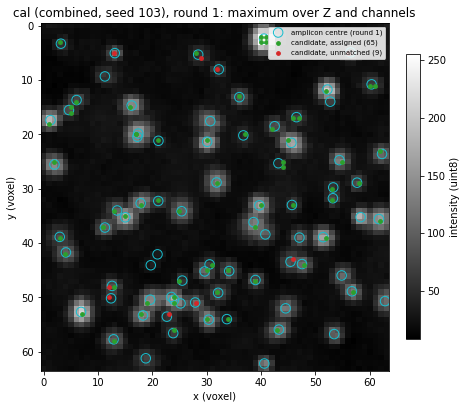

In [13]:
from starfinder.evaluation.matching import match_points

MATCH = dict(policy="greedy", threshold=3.0, units="voxel", boundary="inclusive")
truth_rounds = cal_scene.round_truth
cal_truth = truth_rounds[truth_rounds.round_label == CAL_ROUNDS[0]].set_index("amplicon_id").loc[
    list(cal_scene.amplicon_ids)]
cal_points = note("cal candidate positions", cal.spot_result.spots[["z", "y", "x"]].to_numpy(float),
                  ("spot", "zyx"))
matches = match_points(cal_truth[["z", "y", "x"]].to_numpy(float), cal_points, reference_metadata=cal_scene.metadata,
                       observed_metadata=cal_scene.metadata,
                       eligible_reference=cal_truth.center_in_bounds.to_numpy(bool), **MATCH)
amplicon_genes = cal_scene.formed.set_index("amplicon_id").loc[list(cal_scene.amplicon_ids)].gene_id.astype(str)
truth_gene = np.full(len(cal_points), None, dtype=object)
for i, j, _ in matches.details["matched_pairs"]:
    truth_gene[j] = amplicon_genes.iloc[i]
cal_reads = cal.scoring_result.table.assign(truth_gene=truth_gene, matched=[g is not None for g in truth_gene])
cal_reads["correct"] = [g is not None and g == c for g, c in zip(cal_reads.truth_gene, cal_reads.gene_id.fillna(""))]
print("match_points:", MATCH, " recall", round(matches.values["recall"], 3), " precision",
      round(matches.values["precision"], 3))
outcome = pd.crosstab(cal_reads.call_status, cal_reads.matched.map({True: "matched", False: "unmatched detection"}))
display(outcome)
assigned = cal_reads[cal_reads.call_status.eq("assigned")]
print(f"assigned reads: {len(assigned)}; matched {int(assigned.matched.sum())}, of which correct "
      f"{int(assigned.correct.sum())} and incorrect {int((assigned.matched & ~assigned.correct).sum())}; "
      f"unmatched detections {int((~assigned.matched).sum())}")

projection = note("cal round 1 projection", cal_scene.rounds[CAL_ROUNDS[0]].max(axis=(0, 3)), ("y", "x"))
fig, axis = plt.subplots(figsize=(6.4, 5.6), dpi=72, constrained_layout=True)
shown = axis.imshow(projection, cmap="gray")
inside = cal_truth[cal_truth.center_in_bounds]
axis.scatter(inside.x, inside.y, s=90, facecolors="none", edgecolors="tab:cyan", linewidths=1.0,
             label="amplicon centre (round 1)")
for status, color in (("assigned", "tab:green"), ("unmatched", "tab:red"), ("ambiguous", "tab:orange"),
                      ("no_signal", "tab:purple")):
    rows = cal_reads[cal_reads.call_status.eq(status)]
    spots = cal.spot_result.spots.set_index("spot_id").loc[rows.spot_id]
    if len(rows):
        axis.scatter(spots.x, spots.y, s=14, color=color, label=f"candidate, {status} ({len(rows)})")
axis.set(title="cal (combined, seed 103), round 1: maximum over Z and channels", xlabel="x (voxel)",
         ylabel="y (voxel)")
axis.legend(loc="upper right", fontsize=7, framealpha=0.85)
fig.colorbar(shown, ax=axis, label="intensity (uint8)", shrink=0.8)
plt.show()

## 5. A direct-readout run

In `direct` mode ([docs/readout-contract.md](../../docs/readout-contract.md), "Direct readout")
the candidates come from detection in every listed round. That is one table with a `round`
column, and coincident candidates of different rounds stay separate rows. Each candidate is
extracted in its **own round only**: the other rounds keep the value 0, `box_voxels` 0 and
`valid=False`, which marks an unavailable measurement, not zero signal. The identity is the
panel gene of the candidate's own (round, channel). The brightest channel never changes it, and
the barcode rules (codeword competition, rescue, required rounds, encodings, end bases) do not
apply. The diagnostic columns `own_channel_rank` and `own_channel_fraction` record when another
channel is brighter. The score uses the own round only.

The cell runs `direct2` through `FOV.run` with the dataset's `readout_mode="direct"`, the
two-round detection plan, `DirectAssignmentConfig`, the score and the default filter. It prints
the read table and the `valid` mask.

In [14]:
DIRECT_PIPELINE = PipelineConfig(spot_finding=DIRECT_PLAN, extraction=NeighborhoodSumConfig(),
                                 decoding=DirectAssignmentConfig(), scoring=ReadScoreConfig(),
                                 filtering=ReadFilterConfig())
direct_data = direct_dataset(WORKSPACE / "direct2")
direct = direct_fov(direct_data).run(DIRECT_PIPELINE)
print("Dataset.readout_mode:", direct_data.readout_mode, " decoding result mode:", direct.decoding_result.readout_mode)
print(direct)
reads = direct.scoring_result.table
display(reads[["spot_id", "round", "channel", "gene_id", "entry_id", "call_status", "call_type", "failure_reason",
               "own_channel_rank", "own_channel_fraction", "qc_score", "qc_rounds"]])
print("genes:", reads.gene_id.tolist())

Dataset.readout_mode: direct  decoding result mode: direct
FOV 'FOV_001' of Dataset 'example' (sample 'sample')
    images:   round1*, round2 — (6, 24, 24, 4) uint16 ZYXC   (* reference)
    channels: ch00, ch01, ch02, ch03
    results:  spot_finding, extraction, decoding, scoring, filtering
      spot_finding  4 spots × [spot_id, z, y, x, ...]
      extraction    4 spots × 4 channels × 2 rounds
      decoding      4 reads — assigned 4
      scoring       4 of 4 reads scored
      filtering     4 accepted / 4 (100.0%), rejected 0


,spot_id,round,channel,gene_id,entry_id,call_status,call_type,failure_reason,own_channel_rank,own_channel_fraction,qc_score,qc_rounds
0,0,round1,ch00,Gfap,round1/ch00,assigned,direct,,1.0,0.485087,0.001463,1.0
1,1,round1,ch02,Gad1,round1/ch02,assigned,direct,,1.0,0.484676,0.000659,1.0
2,2,round2,ch01,Sst,round2/ch01,assigned,direct,,1.0,0.484175,0.003220,1.0
3,3,round2,ch03,Aqp4,round2/ch03,assigned,direct,,1.0,0.484443,0.000147,1.0


genes: ['Gfap', 'Gad1', 'Sst', 'Aqp4']


In [15]:
result = direct.intensity_result
own = [result.round_labels.index(r) for r in direct.spot_result.spots["round"]]
mask = pd.DataFrame(result.valid, columns=result.round_labels, index=pd.Index(result.spot_ids, name="spot_id"))
mask["own_round"] = direct.spot_result.spots["round"].to_numpy()
mask["box_voxels"] = [result.box_voxels[i].tolist() for i in range(len(own))]
mask["sum_of_other_round"] = [float(result.values[i, :, 1 - o].sum()) for i, o in enumerate(own)]
print("valid (spot x round), with the box voxels per round and the sum over channels of the other round:")
display(mask)
other_unavailable = all(not result.valid[i, 1 - o] for i, o in enumerate(own))
own_available = all(result.valid[i, o] for i, o in enumerate(own))
print("valid=False for every candidate's other round:", other_unavailable, " own round valid:", own_available)

valid (spot x round), with the box voxels per round and the sum over channels of the other round:


,round1,round2,own_round,box_voxels,sum_of_other_round
spot_id,,,,,
0,True,False,round1,"[75, 0]",0.0
1,True,False,round1,"[75, 0]",0.0
2,False,True,round2,"[0, 75]",0.0
3,False,True,round2,"[0, 75]",0.0


valid=False for every candidate's other round: True  own round valid: True


**Mode checks.** A decoder declares the readout modes it supports. A decoder that does not
support the dataset's mode raises `TypeError` naming both. In `multiplexed` mode a candidate
table with a `round` column raises `ValueError` naming the readout mode. Deduplication is not
available in `direct` mode: there, different channels and rounds are different genes, and no
read is merged automatically. A (round, channel) that the panel does not name (for example a
stain channel) gives `unmatched` with `unmapped_channel`, not an error. The cell shows each
case. `FOV.run` logs a failed run before it raises, so each error also appears as a log line.

In [16]:
print("WTA in direct mode:", error_of(lambda: direct_fov(direct_dataset(WORKSPACE / "direct-wta")).run(
    replace(DIRECT_PIPELINE, decoding=WtaDecoderConfig()))))
print("\ndeduplication in direct mode:", error_of(lambda: direct_fov(direct_dataset(WORKSPACE / "direct-dedup")).run(
    replace(DIRECT_PIPELINE, deduplication=DeduplicationConfig()))))
multiplexed = Dataset(WORKSPACE / "direct-multiplexed", WORKSPACE / "direct-multiplexed" / "out", "example", "sample",
                      "out", rounds=RoundState(sequencing_rounds=list(DIRECT_ROUNDS), reference_round="round1"),
                      channel_order=list(CHANNELS))
multiplexed.codebook = Codebook(pd.DataFrame({"gene_id": ["Gfap"], "color_sequence": ["12"]}), DIRECT_ROUNDS, CHANNELS)
print("\na round column in multiplexed mode:", error_of(lambda: direct_fov(multiplexed).run(
    replace(DIRECT_PIPELINE, decoding=WtaDecoderConfig()))))
without_sst = direct_fov(direct_dataset(WORKSPACE / "direct-no-sst",
                                        panel=DIRECT_MAPPING[DIRECT_MAPPING.gene_id != "Sst"])).run(DIRECT_PIPELINE)
print("\nthe panel without Sst (round2, ch01):")
display(without_sst.decoding_result.table[["spot_id", "round", "channel", "gene_id", "call_status", "failure_reason",
                                           "call_type"]])

[FOV_001] Failed run: readout mode 'direct' does not support decoder 'wta', which supports multiplexed


[FOV_001] Failed run: deduplication is not available in readout mode 'direct': different channels and rounds are different genes there, and no direct-mode read is merged or reassigned


[FOV_001] Failed run: decoding candidates from several detection rounds needs a readout mode (§2.8): set readout_mode='direct' on the dataset for direct readout


WTA in direct mode: TypeError: readout mode 'direct' does not support decoder 'wta', which supports multiplexed

deduplication in direct mode: ValueError: deduplication is not available in readout mode 'direct': different channels and rounds are different genes there, and no direct-mode read is merged or reassigned

a round column in multiplexed mode: ValueError: decoding candidates from several detection rounds needs a readout mode (§2.8): set readout_mode='direct' on the dataset for direct readout

the panel without Sst (round2, ch01):


,spot_id,round,channel,gene_id,call_status,failure_reason,call_type
0,0,round1,ch00,Gfap,assigned,,direct
1,1,round1,ch02,Gad1,assigned,,direct
2,2,round2,ch01,<NA>,unmatched,unmapped_channel,no_call
3,3,round2,ch03,Aqp4,assigned,,direct


## 6. Background and noise

Extraction is unchanged ([docs/readout-baseline.md](../../docs/readout-baseline.md)): per
candidate, channel and round, the sum over a box of half-widths (1, 2, 2) voxels around the
rounded centre, clipped at the image faces. §2.8 adds `box_voxels`, the number of voxels each box
summed, so clipping is visible. It also adds a local background and noise, measured by default
(`NeighborhoodSumConfig.background = LocalBackgroundConfig()`; `None` turns it off). The
estimator is W-278's `local_ring`:

* the ring is the voxels of the outer box (1, 6, 6) outside the inner box (1, 3, 3): the
  extraction box's own three z-planes at lateral Chebyshev distance 4 to 6, 360 voxels when
  unclipped;
* `background` is the ring's median and `noise` is 1.4826 × its median absolute deviation, in
  grey levels per voxel. A box's background in sum units is `background × box_voxels`;
* with fewer than `min_voxels` (16, provisional) ring voxels inside the image, both are NaN;
* `image_background` and `image_noise` (the median and scaled MAD of the whole round and
  channel, the §2.7 noise record) are kept beside them.

The ring is not masked for other spots. W-278 measured that a neighbour centred in the ring
raises the median by about 2 grey levels at the calibrated density. That bias is recorded, not
removed.

The `golden` fixture shows these numbers against known values. It is the fixture of the W-279
golden test (`test_readout_golden.py`), rebuilt here: 12×48×48 uint16, four channels and four
rounds, a background of 20 grey levels with noise sd 3, and ten hand-placed candidates. Each
spot adds a Gaussian of amplitude 800 (sd 1.0 in Z, 1.2 in Y and X) to the channel of its color
in each round, and 5 % of it to the next channel. The fixture also plants the features listed
in `GOLDEN_SPOTS`. The cell checks that the rebuilt images have the golden test's pinned SHA-256
digests.

In [17]:
GOLDEN_SHAPE = (12, 48, 48)
GOLDEN_SEED = 20261002
GOLDEN_METADATA = ImageMetadata("golden/FOV_001")
GOLDEN_NAMESPACE = json.dumps(["golden", "sample", "FOV_001", None])
GOLDEN_CODEWORDS = {"1234": "GeneA", "2143": "GeneB", "3412": "GeneC", "4321": "GeneD",
                    "2222": "GeneE", "3131": "GeneF", "4242": "GeneG", "1313": "GeneH"}
# spot_id -> (z, y, x, planted color sequence, feature).
GOLDEN_SPOTS = {
    "0": (6.0, 12.0, 12.0, "1234", "clean"),
    "1": (6.0, 12.0, 36.0, "2143", "clean"),
    "2": (5.0, 24.0, 24.0, "3412", "clean"),
    "3": (6.0, 1.0, 24.0, "4321", "near the y=0 face: box clipped to y 0-3"),
    "4": (6.0, 36.0, 12.0, "2222", "round2: ch01 and ch02 tie exactly"),
    "5": (6.0, 36.0, 36.0, "3131", "round4: zero in every channel"),
    "6": (4.0, 24.0, 8.0, "1234", "round3: ch03 slightly above ch02 (observed 1244)"),
    "7": (8.0, 24.0, 40.0, "2424", "two substitutions from every codeword"),
    "8": (4.0, 40.0, 24.0, "4242", "clean"),
    "9": (8.0, 8.0, 24.0, "1313", "clean"),
}
# The SHA-256 digests (over dtype, shape and bytes) pinned by test_readout_golden.py, PINNED_INPUT.
GOLDEN_PINNED_INPUT = {
    "round1": "a639da573a740379e5ffc89bd8c3ff3837402f664116a7e0ee141a35f0ff6e06",
    "round2": "abe3b5e1e8dd43528e8f25cd39f008993620944b897363d38c7a8bd86301198c",
    "round3": "e5070fa8b009cd1dbe570ad86d75a7e43b3da43124a21d348f0c909127296fee",
    "round4": "5c2c313146fe7970c367f2ea273cabc75e41eb276bef6be0b4569d0ccdf95175",
}


def gaussian(center, shape):
    z, y, x = (note("gaussian grid", g, ("z", "y", "x"))
               for g in np.meshgrid(*(np.arange(n, dtype=np.float64) for n in shape), indexing="ij"))
    cz, cy, cx = center
    return note("gaussian spot", np.exp(-((z - cz) / 1.0) ** 2 / 2 - ((y - cy) / 1.2) ** 2 / 2
                                        - ((x - cx) / 1.2) ** 2 / 2), ("z", "y", "x"))


def golden_rounds():
    # uint16 ZYXC image per round, every value from GOLDEN_SEED (test_readout_golden.fixture_rounds).
    rng = np.random.RandomState(GOLDEN_SEED)
    images = {}
    for r, label in enumerate(rounds(4)):
        image = note("golden float image", 20.0 + rng.normal(0.0, 3.0, GOLDEN_SHAPE + (4,)),
                     ("z", "y", "x", "channel"))
        for spot_id, (z, y, x, colors, _) in GOLDEN_SPOTS.items():
            blob = gaussian((z, y, x), GOLDEN_SHAPE)
            if spot_id == "6" and r == 2:
                image[..., 2] += 0.85 * 800.0 * blob
                image[..., 3] += 800.0 * blob
                continue
            channel = int(colors[r]) - 1
            image[..., channel] += 800.0 * blob
            image[..., (channel + 1) % 4] += 0.05 * 800.0 * blob
        image = np.clip(np.rint(image), 0, 65535).astype(np.uint16)
        if r == 1:  # spot 4: ch02 of its region becomes ch01 (an exact tie)
            region = tuple(slice(max(int(c) - h, 0), int(c) + h + 1) for c, h in zip((6, 36, 12), (3, 4, 4)))
            image[region + (2,)] = image[region + (1,)]
        if r == 3:  # spot 5: its region is 0 in every channel
            image[tuple(slice(max(int(c) - h, 0), int(c) + h + 1) for c, h in zip((6, 36, 36), (3, 4, 4)))] = 0
        images[label] = image
    return keep("golden", images)


def sha256(array):
    array = np.ascontiguousarray(array)
    h = hashlib.sha256(f"{array.dtype.str}|{array.shape}|".encode())
    h.update(array.tobytes())
    return h.hexdigest()


def golden_candidates():
    # The hand-placed candidates (no detection runs).
    spots = pd.DataFrame({"spot_id": pd.array(list(GOLDEN_SPOTS), dtype="string"),
                          "z": [v[0] for v in GOLDEN_SPOTS.values()], "y": [v[1] for v in GOLDEN_SPOTS.values()],
                          "x": [v[2] for v in GOLDEN_SPOTS.values()]})
    return SpotFindingResult(spots, GOLDEN_METADATA, GOLDEN_NAMESPACE, LocalMaximaConfig(),
                             {"channel_labels": list(CHANNELS)})


def golden_dataset(root):
    root.mkdir(parents=True, exist_ok=True)
    dataset = Dataset(root, root / "out", "golden", "sample", "out",
                      rounds=RoundState(sequencing_rounds=list(rounds(4)), reference_round="round1"),
                      channel_order=list(CHANNELS))
    path = root / "codebook.csv"
    path.write_text("".join(f"{gene},{decode_color_sequence(colors, 'C')[::-1]}\n"
                            for colors, gene in GOLDEN_CODEWORDS.items()))
    dataset.load_codebook(path)
    return dataset


def golden_fov(root, pipeline, checkpoints=None):
    # FOV.run on the golden rounds and its hand-placed candidates.
    fov = golden_dataset(root).fov("FOV_001")
    fov.images = golden_rounds()
    fov.metadata = {label: GOLDEN_METADATA for label in rounds(4)}
    fov.spot_result = golden_candidates()
    return fov.run(pipeline, checkpoints=checkpoints)


images = golden_rounds()
print("golden rounds:", {label: f"{image.shape} {image.dtype}" for label, image in images.items()})
print("equal to the golden test's pinned inputs:", {label: sha256(image) == GOLDEN_PINNED_INPUT[label]
                                                   for label, image in images.items()})
display(pd.DataFrame([dict(spot_id=k, z=v[0], y=v[1], x=v[2], planted=v[3], feature=v[4])
                      for k, v in GOLDEN_SPOTS.items()]))

golden rounds: {'round1': '(12, 48, 48, 4) uint16', 'round2': '(12, 48, 48, 4) uint16', 'round3': '(12, 48, 48, 4) uint16', 'round4': '(12, 48, 48, 4) uint16'}
equal to the golden test's pinned inputs: {'round1': True, 'round2': True, 'round3': True, 'round4': True}


,spot_id,z,y,x,planted,feature
0,0,6.0,12.0,12.0,1234,clean
1,1,6.0,12.0,36.0,2143,clean
2,2,5.0,24.0,24.0,3412,clean
3,3,6.0,1.0,24.0,4321,near the y=0 face: box clipped to y 0-3
4,4,6.0,36.0,12.0,2222,round2: ch01 and ch02 tie exactly
5,5,6.0,36.0,36.0,3131,round4: zero in every channel
6,6,4.0,24.0,8.0,1234,round3: ch03 slightly above ch02 (observed 1244)
7,7,8.0,24.0,40.0,2424,two substitutions from every codeword
8,8,4.0,40.0,24.0,4242,clean
9,9,8.0,8.0,24.0,1313,clean


The next cell extracts the golden candidates with the defaults and prints, for round 1, the
voxels each box summed, the ring voxels inside the image, and the background and noise of the
four channels. Away from the spots the analytic answer is a background of 20 and a noise of 3
grey levels. On integer data the MAD moves in whole grey levels, so a MAD of 2 gives the noise
1.4826 × 2 = 2.9652. Spot 3 sits at y = 1. Its box is clipped to y 0–3 (60 of 75 voxels), and its ring
keeps only the voxels inside the image.

In [18]:
golden_extraction = golden_fov(WORKSPACE / "golden-extraction", PipelineConfig(extraction=NeighborhoodSumConfig()))
extraction = golden_extraction.intensity_result
show(extraction.config)
rows = []
for i, spot_id in enumerate(extraction.spot_ids):
    rows.append(dict(spot_id=spot_id, feature=GOLDEN_SPOTS[spot_id][4], box_voxels=int(extraction.box_voxels[i, 0]),
                     ring_voxels=int(extraction.background_voxels[i, 0]),
                     background=extraction.background[i, :, 0].tolist(), noise=extraction.noise[i, :, 0].round(4).tolist()))
with pd.option_context("display.max_colwidth", 60):
    display(pd.DataFrame(rows))
print("image_background (channel x round):\n", extraction.image_background)
print("image_noise (channel x round):\n", extraction.image_noise.round(4))

NeighborhoodSumConfig(neighborhood_radius_zyx=(1, 2, 2), sampling='nearest', boundary='zero', background=LocalBackgroundConfig(inner_radius_zyx=(1, 3, 3), outer_radius_zyx=(1, 6, 6), min_voxels=16))


,spot_id,feature,box_voxels,ring_voxels,background,noise
0,0,clean,75,360,"[20.0, 20.0, 20.0, 20.0]","[2.9652, 2.9652, 2.9652, 2.9652]"
1,1,clean,75,360,"[20.0, 21.0, 20.0, 20.0]","[2.9652, 2.9652, 2.9652, 2.9652]"
2,2,clean,75,360,"[20.0, 20.0, 20.0, 20.0]","[2.9652, 2.9652, 2.9652, 2.9652]"
3,3,near the y=0 face: box clipped to y 0-3,60,207,"[21.0, 20.0, 20.0, 20.0]","[4.4478, 2.9652, 2.9652, 2.9652]"
4,4,round2: ch01 and ch02 tie exactly,75,360,"[20.0, 20.0, 20.0, 20.0]","[2.9652, 2.9652, 2.9652, 2.9652]"
5,5,round4: zero in every channel,75,360,"[20.0, 20.0, 20.0, 20.0]","[2.9652, 2.9652, 2.9652, 2.9652]"
6,6,round3: ch03 slightly above ch02 (observed 1244),75,360,"[20.0, 20.0, 20.0, 20.0]","[2.9652, 2.9652, 2.9652, 2.9652]"
7,7,two substitutions from every codeword,75,360,"[20.0, 20.0, 20.0, 20.0]","[2.9652, 2.9652, 2.9652, 2.9652]"
8,8,clean,75,360,"[20.0, 20.0, 20.0, 20.0]","[2.9652, 2.9652, 2.9652, 2.9652]"
9,9,clean,75,360,"[20.0, 20.0, 20.0, 21.0]","[2.9652, 2.9652, 2.9652, 2.9652]"


image_background (channel x round):
 [[20. 20. 20. 20.]
 [20. 20. 20. 20.]
 [20. 20. 20. 20.]
 [20. 20. 20. 20.]]
image_noise (channel x round):
 [[2.9652 2.9652 2.9652 2.9652]
 [2.9652 2.9652 2.9652 2.9652]
 [2.9652 2.9652 2.9652 2.9652]
 [2.9652 2.9652 2.9652 2.9652]]


The figure draws the geometry for spot 2 (z = 5) on its z-plane in round 1, channel ch02 (color
3): the extraction box (1, 2, 2), the excluded inner box (1, 3, 3) and the outer box (1, 6, 6).
The ring is the band between the inner and the outer square, on the box's own three z-planes.

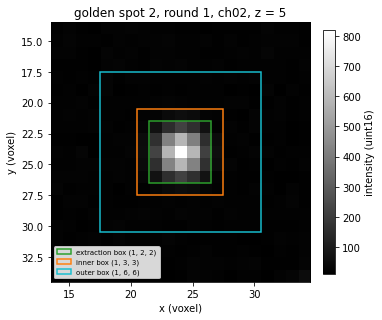

In [19]:
z, y, x = (int(v) for v in GOLDEN_SPOTS["2"][:3])
plane = note("golden round 1 plane", images["round1"][z, :, :, 2], ("y", "x"))
fig, axis = plt.subplots(figsize=(5.2, 4.6), dpi=72, constrained_layout=True)
shown = axis.imshow(plane[y - 10:y + 11, x - 10:x + 11], cmap="gray", extent=(x - 10.5, x + 10.5, y + 10.5, y - 10.5))
for half, color, label in ((2, "tab:green", "extraction box (1, 2, 2)"), (3, "tab:orange", "inner box (1, 3, 3)"),
                           (6, "tab:cyan", "outer box (1, 6, 6)")):
    axis.add_patch(plt.Rectangle((x - half - 0.5, y - half - 0.5), 2 * half + 1, 2 * half + 1, fill=False,
                                 edgecolor=color, linewidth=1.5, label=label))
axis.set(title=f"golden spot 2, round 1, ch02, z = {z}", xlabel="x (voxel)", ylabel="y (voxel)")
axis.legend(loc="lower left", fontsize=7, framealpha=0.85)
fig.colorbar(shown, ax=axis, label="intensity (uint16)", shrink=0.8)
plt.show()

On the calibrated scene the background varies with the channel, round and position (pedestal,
gradient, regions, texture and correlated noise). The cell prints the medians that
`summarize_reads` reports for the `cal` run, per round and channel: the medians over candidates
of the local `background` and `noise`, next to the image-wide `image_background` and
`image_noise`. It ends by turning the measurement off: scoring then raises and names
extraction. W-278 chose the ring on its design seeds by its error against the realized
background (median 2.22 grey levels, held out 2.28). It also lists the ring's limits: it tracks
the realized, not the latent background; its MAD underestimates the analytic noise by about 12 %
on clipped uint8 data; and the evidence is synthetic only
([docs/readout-algorithms.md](../../docs/readout-algorithms.md), "Background and noise").

In [20]:
medians = cal_summary["intensities"]["medians"]
cal_extraction = cal.intensity_result
rows = []
for r, label in enumerate(cal_extraction.round_labels):
    for c, channel in enumerate(cal_extraction.channel_labels):
        rows.append(dict(round=label, channel=channel, background_median=medians[label][channel]["background"],
                         noise_median=medians[label][channel]["noise"],
                         image_background=cal_extraction.image_background[c, r],
                         image_noise=round(float(cal_extraction.image_noise[c, r]), 4)))
display(pd.DataFrame(rows).pivot(index="channel", columns="round",
                                 values=["background_median", "image_background", "noise_median", "image_noise"]))
print("ring voxels per candidate and round: min", int(cal_extraction.background_voxels.min()), " median",
      float(np.median(cal_extraction.background_voxels)), " max", int(cal_extraction.background_voxels.max()))
print("background unavailable:", cal_summary["intensities"]["background_unavailable"])
print("\nscoring without background:", error_of(lambda: cal_fov(WORKSPACE / "cal-no-background", replace(
    CAL_PIPELINE, extraction=NeighborhoodSumConfig(background=None)))))

background_median                      image_background                      noise_median                         image_noise                      
round              round1 round2 round3 round4           round1 round2 round3 round4       round1  round2  round3  round4      round1  round2 round3 round4
channel                                                                                                                                                    
ch00                  8.0    9.0   11.0    8.5              8.0    9.0    9.0    8.0       5.9304  5.9304  5.9304  5.9304       7.413  7.4130  7.413  7.413
ch01                  8.0   10.0   10.0   11.0              8.0    9.0   10.0   10.0       5.9304  7.4130  5.9304  7.4130       7.413  8.8956  7.413  7.413
ch02                  9.0    8.0    9.0    9.5              8.0    8.0    8.0    9.0       7.4130  5.9304  5.9304  7.4130       7.413  7.4130  7.413  7.413
ch03                  7.0    8.5    8.0    8.0              7.0    8.0    7.0    7.0       5.9304  5.9304  5.9304  5.9304       7.413  7.4130  7.413  7.413

[FOV_001] Failed run: scoring needs the local background measured at extraction, and these intensities have none (NeighborhoodSumConfig.background=None, or a candidates checkpoint written without it); rerun extraction with NeighborhoodSumConfig.background=LocalBackgroundConfig()


ring voxels per candidate and round: min 153  median 360.0  max 360
background unavailable: {'round1': 0, 'round2': 0, 'round3': 0, 'round4': 0}

scoring without background: ValueError: scoring needs the local background measured at extraction, and these intensities have none (NeighborhoodSumConfig.background=None, or a candidates checkpoint written without it); rerun extraction with NeighborhoodSumConfig.background=LocalBackgroundConfig()


## 7. The shared score

`score_reads` adds one ranking of call reliability for every decoder (WTA, codebook-aware and
direct), for exact and rescued calls, and for both modes
([docs/readout-contract.md](../../docs/readout-contract.md), "Shared read-QC score"). `qc_score`
is W-278 design D1: the decoder's probability NLL of the assigned entry, recomputed on
background-subtracted sums. For each used round, `v'_c = max(v_c − box_voxels × background_c,
0)`, `p = (v'_a + 1e-6) / Σ_c (v'_c + 1e-6)` at the assigned channel `a`, and
`qc_score = Σ_r −log max(p, 1e-12)`. Lower ranks as more reliable. The components kept beside it
are `qc_ambiguity_max` (the strongest other channel over the assigned one),
`qc_signal_to_background` and `qc_rounds`. Reads without an identity get NaN with the reason
`no_assignment`, and reads with a round without background get `background_unavailable`. The
score never changes `gene_id`, `entry_id`, `call_status` or `call_type`, and it has no tunable
parameter.

What it is not, in W-278's words (the W-278 worker notes, "Limitations"):

> Every score is a ranking, not a probability; none is calibrated.

So the notebook draws no cutoff on it, and the default filter bounds no score (section 9).
The cell prints the score columns of the first reads of the `cal` run, the reasons, and the
check that scoring changed no identity column.

In [21]:
scored = cal.scoring_result
show(scored)
show(scored.config)
display(scored.table[["spot_id", "gene_id", "call_status", "call_type", "wta_l2_nll", "qc_score", "qc_ambiguity_max",
                      "qc_signal_to_background", "qc_rounds", "qc_reason"]].head(8))
print("qc_reason:", scored.table.qc_reason.replace("", "(scored)").value_counts().to_dict())
identity = ["spot_id", "gene_id", "entry_id", "call_status", "call_type"]
print("identity columns unchanged by scoring:",
      scored.table[identity].equals(cal.decoding_result.table[identity]))
print("summarize_reads qc_score quantiles per call_type:", cal_summary["qc_score"])

ReadScoringResult: 65 of 74 reads scored — no_assignment 9
ReadScoreConfig(method='bgcorr_probability')


,spot_id,gene_id,call_status,call_type,wta_l2_nll,qc_score,qc_ambiguity_max,qc_signal_to_background,qc_rounds,qc_reason
0,0,balanced-03,assigned,exact,0.068708,0.367356,0.095105,9.587425,4.0,
1,1,balanced-03,assigned,exact,0.061958,0.334756,0.083959,9.760742,4.0,
2,2,balanced-03,assigned,exact,0.063480,0.277881,0.092013,10.668944,4.0,
3,3,balanced-03,assigned,exact,0.057840,0.233650,0.083472,11.681818,4.0,
4,4,balanced-02,assigned,exact,0.341420,0.882871,0.332412,5.922863,4.0,
5,5,balanced-03,assigned,exact,0.337997,1.101392,0.378679,9.825096,4.0,
6,6,balanced-02,assigned,exact,0.107212,0.158211,0.132219,6.258606,4.0,
7,7,balanced-02,assigned,exact,0.216997,0.572902,0.163374,4.521722,4.0,


qc_reason: {'(scored)': 65, 'no_assignment': 9}
identity columns unchanged by scoring: True
summarize_reads qc_score quantiles per call_type: {'exact': {'n': 65, 'q05': 0.2702863747804038, 'q25': 0.5043066554662878, 'q50': 0.7027959329600012, 'q75': 1.0629506551050547, 'q95': 1.8082565638042412}}


**Ranking on the calibrated scene.** `ranking_quality` gives the W-278 ranking measures: the
AUROC (the probability that a correct call ranks above an incorrect one), its Hanley–McNeil
standard error, and the incorrect fraction among the best-ranked 50, 80, 90 and 100 % of calls.
The cell applies it as check R12 does: to the exact WTA calls with a matched amplicon, once for
`qc_score` and once for the decoder's own score `wta_l2_nll` (lower is more reliable for both).
The unmatched detections are counted apart.

One scene holds very few incorrect calls, so its AUROC carries little information: the printed
standard error shows it. The evidence for the design is pooled. On the W-278 held-out scenes
(nine conditions × seeds 103 to 105, 46 incorrect exact calls), `qc_score` ranks exact calls at
AUROC 0.897 against 0.782 (WTA) and 0.743 (codebook-aware). Rescued calls are at 0.851 against
0.670. Check R12 reproduces these values in the extended tier
([docs/readout-algorithms.md](../../docs/readout-algorithms.md), "Implemented checks (W-296)"). The figure plots the two scores of each
exact call. It draws no threshold.

,score,auroc,auroc_se,error_at_50,error_at_80,error_at_90,error_at_100,total,scored,correct,incorrect,score_undefined
0,qc_score,0.3304,0.3018,0.0345,0.0217,0.0192,0.0175,57,57,56,1,0
1,wta_l2_nll,0.1875,0.2642,0.0345,0.0217,0.0192,0.0175,57,57,56,1,0


{'orientation': 'lower', 'retention': [0.5, 0.8, 0.9, 1.0], 'ties': 'one half (AUROC), proportional at the retention boundary', 'standard_error': 'Hanley-McNeil 1982'}
unmatched detections among the exact calls (not ranked): 8


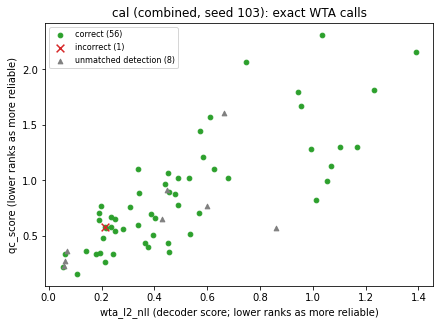

In [22]:
from starfinder.evaluation.barcode import ranking_quality

exact = cal_reads[cal_reads.call_status.eq("assigned") & cal_reads.call_type.eq("exact")]
calls = exact[exact.matched]
rows = []
for column in ("qc_score", "wta_l2_nll"):
    quality = ranking_quality(calls[column].to_numpy(), calls.correct.to_numpy(dtype=bool), orientation="lower")
    rows.append(dict(score=column, **{k: (None if v is None else round(v, 4)) for k, v in quality.values.items()},
                     **quality.counts))
display(pd.DataFrame(rows))
show(quality.config)
print("unmatched detections among the exact calls (not ranked):", int((~exact.matched).sum()))

fig, axis = plt.subplots(figsize=(6.0, 4.4), dpi=72, constrained_layout=True)
for label, rows_, style in (("correct", calls[calls.correct], dict(color="tab:green", marker="o")),
                            ("incorrect", calls[~calls.correct], dict(color="tab:red", marker="x", s=60)),
                            ("unmatched detection", exact[~exact.matched], dict(color="tab:gray", marker="^"))):
    axis.scatter(rows_.wta_l2_nll, rows_.qc_score, label=f"{label} ({len(rows_)})", **{"s": 22, **style})
axis.set(xlabel="wta_l2_nll (decoder score; lower ranks as more reliable)",
         ylabel="qc_score (lower ranks as more reliable)",
         title="cal (combined, seed 103): exact WTA calls")
axis.legend(fontsize=8)
plt.show()

## 8. Deduplication

Crosstalk can make one amplicon a candidate in two channels, and both candidates are then read.
Optional deduplication (`DeduplicationConfig`, off by default) marks the second read as a
duplicate ([docs/readout-contract.md](../../docs/readout-contract.md), "Optional
deduplication"):

* **link:** two candidates of one detection round in different channels, at most
  `distance_voxels` apart (1.0, inclusive, in voxel index space), with identical WTA observed
  color sequences that contain no `M` (tie) or `N`;
* **group:** the connected components of the links;
* **representative:** an original candidate, never a new or averaged one. It is the member with
  the largest sum in its own detection channel among the assigned members (among all members
  when none is assigned); ties go to the earliest row;
* **conflict:** a group whose assigned members are of different entries is not merged. Every
  member stays a representative, with the reason `conflicting_calls`.

Every row is kept. The stage adds `duplicate_group`, `duplicate_of`, `is_representative` and
`duplicate_reason`, and the filter rejects duplicates (section 9). W-278 measured the pairwise
link only. The grouping, the representative and the conflict rule are proposals it did not
measure, so the checks that rest on them are provisional.

The `crosstalk` fixture (seed 100) is built as the validation fixture is. It is 16×64×64 uint16
with four channels and four rounds, and the same background, noise and spot shape as `golden`.
It holds 20 amplicons of the eight golden genes, each with a 5 % copy of its signal in the next
channel. The copies sit at known offsets: 8 at 0, 4 at 1, 4 at √2 and 4 at 2 voxels. It also
holds 6 pairs of amplicons of different genes 1 voxel apart, in different channels, and one
amplicon (color sequence 2311) with a copy 1 voxel along Z. Two added Gaussians make that
amplicon's source rescue to GeneY and its copy to GeneX, a conflicting group. Every candidate is
placed by hand at a planted position with its detection channel, so no detection runs.

In [23]:
CROSSTALK_SHAPE = (16, 64, 64)
CROSSTALK_CODEWORDS = {"1234": "GeneA", "2143": "GeneB", "3412": "GeneC", "4321": "GeneD", "2222": "GeneE",
                       "3131": "GeneF", "4242": "GeneG", "1313": "GeneH", "2341": "GeneX", "2314": "GeneY"}
SLOTS = [(z, y, x) for z in (5.0, 11.0) for y in (8.0, 20.0, 32.0, 44.0, 56.0) for x in (8.0, 20.0, 32.0, 44.0, 56.0)]
COPY_OFFSETS = ([(0, 0, 0)] * 8 + [(1, 0, 0), (0, 1, 0), (0, 0, 1), (0, -1, 0)]
                + [(0, 1, 1), (1, 1, 0), (0, 1, -1), (1, 0, 1)] + [(0, 2, 0), (0, 0, 2), (0, -2, 0), (0, 0, -2)])
DIFFERENT_GENE_PAIRS = [("1234", "2143"), ("3412", "4321"), ("2222", "3131"), ("4242", "1313"), ("1234", "3412"),
                        ("2143", "4321")]


def crosstalk_amplicons():
    # (amplicon, centre, color sequence, copy offset or None, kind) of every planted amplicon.
    genes, amplicons, slot = list(CROSSTALK_CODEWORDS)[:8], [], 0
    for i, offset in enumerate(COPY_OFFSETS):
        amplicons.append((f"a{i}", SLOTS[slot], genes[i % 8], offset, "copy"))
        slot += 1
    for p, (a, b) in enumerate(DIFFERENT_GENE_PAIRS):
        z, y, x = SLOTS[slot]
        slot += 1
        amplicons += [(f"p{p}a", (z, y, x), a, None, "pair"), (f"p{p}b", (z, y, x + 1.0), b, None, "pair")]
    amplicons.append(("c0", SLOTS[slot], "2311", (1, 0, 0), "conflict"))
    return amplicons


def crosstalk_truth():
    # One row per candidate: position, round-1 detection channel, source amplicon, role, copy distance and kind.
    rows = []
    for amplicon, center, colors, offset, kind in crosstalk_amplicons():
        channel = int(colors[0]) - 1
        distance = np.nan if offset is None else float(np.linalg.norm(offset))
        rows.append(dict(z=center[0], y=center[1], x=center[2], channel=channel, source=amplicon, role="source",
                         distance=distance, kind=kind))
        if offset is not None:
            z, y, x = np.add(center, offset)
            rows.append(dict(z=float(z), y=float(y), x=float(x), channel=(channel + 1) % 4, source=amplicon,
                             role="copy", distance=distance, kind=kind))
    return pd.DataFrame(rows)


def crosstalk_rounds(seed=100):
    rng = np.random.RandomState(seed)
    amplicons = crosstalk_amplicons()
    blobs = {}

    def blob(center):
        key = tuple(float(c) for c in center)
        if key not in blobs:
            blobs[key] = gaussian(key, CROSSTALK_SHAPE)
        return blobs[key]

    z, y, x = next(center for _, center, _, _, kind in amplicons if kind == "conflict")
    images = {}
    for r, label in enumerate(rounds(4)):
        image = note("crosstalk float image", 20.0 + rng.normal(0.0, 3.0, CROSSTALK_SHAPE + (4,)),
                     ("z", "y", "x", "channel"))
        for _, center, colors, offset, _ in amplicons:
            channel = int(colors[r]) - 1
            image[..., channel] += 800.0 * blob(center)
            if offset is not None:
                image[..., (channel + 1) % 4] += 0.05 * 800.0 * blob(np.add(center, offset))
        if r == 2:  # round 3 ambiguous at the copy: GeneX's channel, 2 voxels beyond the source
            image[..., int("2341"[2]) - 1] += 0.85 * 800.0 * blob((z + 2, y, x))
        if r == 3:  # round 4 ambiguous at the source: GeneY's channel, 1 voxel before it
            image[..., int("2314"[3]) - 1] += 1.1 * 800.0 * blob((z - 1, y, x))
        images[label] = np.clip(np.rint(image), 0, 65535).astype(np.uint16)
    return keep("crosstalk", images)


def crosstalk_fov(root, deduplication):
    # FOV.run of the crosstalk fixture: hand-placed candidates, codebook-aware decoding, score, filter.
    root.mkdir(parents=True, exist_ok=True)
    dataset = Dataset(root, root / "out", "crosstalk", "sample", "out",
                      rounds=RoundState(sequencing_rounds=list(rounds(4)), reference_round="round1"),
                      channel_order=list(CHANNELS))
    path = root / "codebook.csv"
    path.write_text("".join(f"{gene},{decode_color_sequence(colors, 'C')[::-1]}\n"
                            for colors, gene in CROSSTALK_CODEWORDS.items()))
    dataset.load_codebook(path)
    truth = crosstalk_truth()
    spots = pd.DataFrame({"spot_id": pd.array([str(i) for i in range(len(truth))], dtype="string"),
                          "z": truth.z.astype(np.float64).to_numpy(), "y": truth.y.astype(np.float64).to_numpy(),
                          "x": truth.x.astype(np.float64).to_numpy(),
                          "channel": truth.channel.astype(np.int64).to_numpy()})
    fov = dataset.fov("FOV_001")
    fov.images = crosstalk_rounds()
    fov.metadata = {label: ImageMetadata("crosstalk/FOV_001") for label in rounds(4)}
    fov.spot_result = SpotFindingResult(spots, ImageMetadata("crosstalk/FOV_001"),
                                        json.dumps(["crosstalk", "sample", "FOV_001", None]), LocalMaximaConfig(),
                                        {"channel_labels": list(CHANNELS)})
    return fov.run(PipelineConfig(extraction=NeighborhoodSumConfig(), decoding=CodebookAwareDecoderConfig(),
                                  scoring=ReadScoreConfig(), deduplication=deduplication, filtering=ReadFilterConfig()))


crosstalk = crosstalk_truth()
print("crosstalk:", {label: f"{image.shape} {image.dtype}" for label, image in crosstalk_rounds().items()})
print("candidates:", len(crosstalk), " by kind and role:", crosstalk.groupby(["kind", "role"]).size().to_dict())
copies = crosstalk[crosstalk.kind.eq("copy") & crosstalk.role.eq("copy")]
print("copy distances of the 20 copy amplicons (voxels):", copies.distance.round(3).value_counts().sort_index().to_dict(),
      " conflict copy:", crosstalk[crosstalk.kind.eq("conflict") & crosstalk.role.eq("copy")].distance.tolist())
with timed("FOV.run on crosstalk, deduplication on and off"):
    dedup_on = crosstalk_fov(WORKSPACE / "crosstalk-on", DeduplicationConfig())
    dedup_off = crosstalk_fov(WORKSPACE / "crosstalk-off", None)
show(DeduplicationConfig())
print("on: ", dedup_on.deduplication_result, "|", dedup_on.filtering_result)
print("off:", dedup_off.deduplication_result, "|", dedup_off.filtering_result)
print("cross-channel pairs within 1 voxel:", dedup_on.deduplication_result.diagnostics["cross_channel_pairs"],
      " linked:", dedup_on.deduplication_result.diagnostics["linked_pairs"])

crosstalk: {'round1': '(16, 64, 64, 4) uint16', 'round2': '(16, 64, 64, 4) uint16', 'round3': '(16, 64, 64, 4) uint16', 'round4': '(16, 64, 64, 4) uint16'}
candidates: 54  by kind and role: {('conflict', 'copy'): 1, ('conflict', 'source'): 1, ('copy', 'copy'): 20, ('copy', 'source'): 20, ('pair', 'source'): 12}
copy distances of the 20 copy amplicons (voxels): {0.0: 8, 1.0: 4, 1.414: 4, 2.0: 4}  conflict copy: [1.0]


DeduplicationConfig(distance_voxels=1.0, compatibility='same_sequence')
on:  ReadDeduplicationResult: 54 reads — 12 groups, 12 merged, 1 conflicting | ReadFilteringResult: 42 accepted / 54 (77.8%), rejected 12 — duplicate 12
off: None | ReadFilteringResult: 54 accepted / 54 (100.0%), rejected 0
cross-channel pairs within 1 voxel: 19  linked: 13


`evaluate_deduplication` counts missed duplicates (pairs of one source left unmerged) and false
merges (merged pairs of different sources) over a stated pair population. Reads that the stage
merged share a label. The reads of a conflicting group are not merged, so they get no label.
The cell evaluates three populations:

* the 12 copies within 1 voxel;
* the 8 copies at √2 and 2 voxels, which d = 1 leaves unmerged as planted;
* the 6 different-gene pairs.

It evaluates all of them once more with the stage off. Then it prints the representative of
each merged copy and the conflicting group.

In [24]:
from starfinder.evaluation.barcode import evaluate_deduplication


def merge_labels(table):
    # Each read's merged-group label; reads of a conflicting group and ungrouped reads get none.
    if "duplicate_reason" not in table:
        return [None] * len(table)
    merged = table.duplicate_reason.eq("same_sequence_within_distance").to_numpy(bool)
    return [str(g) if m else None for g, m in zip(table.duplicate_group, merged)]


def copy_pairs(select):
    pairs = []
    for _, rows in crosstalk[crosstalk.kind.eq("copy")].groupby("source", sort=False):
        source, copy = rows.index[rows.role.eq("source")][0], rows.index[rows.role.eq("copy")][0]
        if select(rows.distance.iloc[0]):
            pairs.append((int(source), int(copy)))
    return pairs


pair_rows = crosstalk.index[crosstalk.kind.eq("pair")].tolist()
POPULATIONS = {"copies at 0 and 1 voxel": copy_pairs(lambda d: d <= 1.0),
               "copies at sqrt(2) and 2 voxels": copy_pairs(lambda d: d > 1.0),
               "different-gene pairs at 1 voxel": list(zip(pair_rows[0::2], pair_rows[1::2]))}
rows = []
for stage, fov in (("on, d = 1", dedup_on), ("off", dedup_off)):
    table = (fov.deduplication_result or fov.scoring_result).table
    labels = merge_labels(table)
    for population, pairs in POPULATIONS.items():
        evaluation = evaluate_deduplication(labels, crosstalk.source.tolist(), pairs=pairs)
        rows.append(dict(deduplication=stage, population=population, pairs=evaluation.counts["pairs"],
                         merged_pairs=evaluation.counts["merged_pairs"],
                         missed_duplicates=evaluation.values["missed_duplicates"],
                         false_merges=evaluation.values["false_merges"]))
    print(f"deduplication {stage}: groups {sum(label is not None for label in set(labels))}, "
          f"columns added {[c for c in table.columns if c in ('duplicate_group', 'duplicate_of', 'is_representative', 'duplicate_reason')]}")
display(pd.DataFrame(rows))

table = dedup_on.deduplication_result.table
representatives = pd.DataFrame([dict(
    source_candidate=a, copy_candidate=b, distance=crosstalk.distance[a], source_channel=CHANNELS[crosstalk.channel[a]],
    copy_channel=CHANNELS[crosstalk.channel[b]], gene=table.gene_id[a],
    source_is_representative=bool(table.is_representative[a]), copy_duplicate_of=table.duplicate_of[b],
) for a, b in POPULATIONS["copies at 0 and 1 voxel"]])
display(representatives)
print("every representative is the source amplicon's own-channel candidate:",
      bool(representatives.source_is_representative.all()
           and (representatives.copy_duplicate_of == representatives.source_candidate.astype(str)).all()))
conflict = crosstalk.index[crosstalk.kind.eq("conflict")].tolist()
print("the conflicting group (source, then its copy 1 voxel along Z):")
display(table.loc[conflict, ["spot_id", "observed_color_sequence", "gene_id", "call_type", "duplicate_group",
                             "duplicate_of", "is_representative", "duplicate_reason"]].assign(
    channel=[CHANNELS[c] for c in crosstalk.channel[conflict]], role=crosstalk.role[conflict].tolist()))

deduplication on, d = 1: groups 12, columns added ['duplicate_group', 'duplicate_of', 'is_representative', 'duplicate_reason']
deduplication off: groups 0, columns added []


,deduplication,population,pairs,merged_pairs,missed_duplicates,false_merges
0,"on, d = 1",copies at 0 and 1 voxel,12,12,0,0
1,"on, d = 1",copies at sqrt(2) and 2 voxels,8,0,8,0
2,"on, d = 1",different-gene pairs at 1 voxel,6,0,0,0
3,off,copies at 0 and 1 voxel,12,0,12,0
4,off,copies at sqrt(2) and 2 voxels,8,0,8,0
5,off,different-gene pairs at 1 voxel,6,0,0,0


,source_candidate,copy_candidate,distance,source_channel,copy_channel,gene,source_is_representative,copy_duplicate_of
0,0,1,0.0,ch00,ch01,GeneA,True,0
1,2,3,0.0,ch01,ch02,GeneB,True,2
2,4,5,0.0,ch02,ch03,GeneC,True,4
3,6,7,0.0,ch03,ch00,GeneD,True,6
4,8,9,0.0,ch01,ch02,GeneE,True,8
5,10,11,0.0,ch02,ch03,GeneF,True,10
6,12,13,0.0,ch03,ch00,GeneG,True,12
7,14,15,0.0,ch00,ch01,GeneH,True,14
8,16,17,1.0,ch00,ch01,GeneA,True,16
9,18,19,1.0,ch01,ch02,GeneB,True,18


every representative is the source amplicon's own-channel candidate: True
the conflicting group (source, then its copy 1 voxel along Z):


,spot_id,observed_color_sequence,gene_id,call_type,duplicate_group,duplicate_of,is_representative,duplicate_reason,channel,role
52,52,2311,GeneY,rescued_h1,52,<NA>,True,conflicting_calls,ch01,source
53,53,2311,GeneX,rescued_h1,52,<NA>,True,conflicting_calls,ch02,copy


The figure shows the candidates of `crosstalk` in YX: kept representatives, the merged
duplicates (an arrow to their representative), the conflicting group, and ungrouped reads.

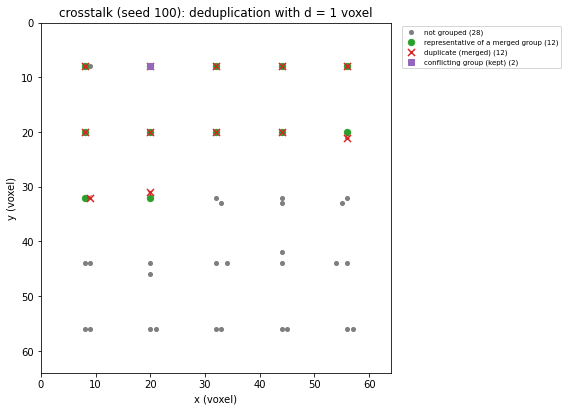

In [25]:
fig, axis = plt.subplots(figsize=(8.6, 5.6), dpi=72, constrained_layout=True)
grouped = table.duplicate_group.notna().to_numpy()
merged = table.duplicate_reason.eq("same_sequence_within_distance").to_numpy()
conflicting = table.duplicate_reason.eq("conflicting_calls").to_numpy()
duplicate = ~table.is_representative.to_numpy(bool)
for label, select, style in (("not grouped", ~grouped, dict(color="tab:gray", marker="o", s=16)),
                             ("representative of a merged group", merged & ~duplicate,
                              dict(color="tab:green", marker="o", s=40)),
                             ("duplicate (merged)", duplicate, dict(color="tab:red", marker="x", s=50)),
                             ("conflicting group (kept)", conflicting, dict(color="tab:purple", marker="s", s=40))):
    axis.scatter(crosstalk.x[select], crosstalk.y[select], label=f"{label} ({int(select.sum())})", **style)
for i in np.flatnonzero(duplicate):
    j = int(table.duplicate_of[i])
    axis.annotate("", (crosstalk.x[j], crosstalk.y[j]), (crosstalk.x[i], crosstalk.y[i]),
                  arrowprops=dict(arrowstyle="->", color="tab:red", lw=0.8))
axis.set(xlim=(0, 64), ylim=(64, 0), xlabel="x (voxel)", ylabel="y (voxel)",
         title="crosstalk (seed 100): deduplication with d = 1 voxel")
axis.set_aspect("equal")
axis.legend(fontsize=7, loc="upper left", bbox_to_anchor=(1.02, 1.0))
plt.show()

## 9. Filtering and the defaults

`filter_reads` with `ReadFilterConfig` accepts or rejects each read and keeps every row, with
`accepted` and `rejection_reasons`. It has explicit predicates only:

* `call_statuses` (default `("assigned",)`);
* inclusive `score_bounds` on any declared score column, which is a decoder's
  `score_columns` or one of the shared score's columns (default: none);
* `exclude_duplicates` (default true; no effect on reads that were not deduplicated);
* end-base checks: `end_bases` (the one-segment shortcut) or the segment ends on the layout.
  They are diagnostic unless `exclude_invalid_endpoints` is true.

**There is no default score cutoff.** The default filter keeps every assigned read and bounds no
score, and no cutoff is recommended: choosing one belongs to the comparisons of E03, on real
data. The cell shows the default and each predicate on the golden WTA reads and on the
deduplicated `crosstalk` reads. The score bound is the golden test's bound on `wta_l2_nll`
(0.069), used here only to show the mechanism; it is not a recommended value.

In [26]:
GOLDEN_WTA = PipelineConfig(extraction=NeighborhoodSumConfig(), decoding=WtaDecoderConfig(),
                            scoring=ReadScoreConfig(), filtering=ReadFilterConfig())
golden_wta = golden_fov(WORKSPACE / "golden-wta", GOLDEN_WTA)
show(ReadFilterConfig())
cases = {"default": ReadFilterConfig(),
         "wta_l2_nll <= 0.069 (the golden test's bound)": ReadFilterConfig(score_bounds={"wta_l2_nll": (None, 0.069)}),
         "end_bases CC, diagnostic": ReadFilterConfig(end_bases="CC"),
         "end_bases CC, excluding": ReadFilterConfig(end_bases="CC", exclude_invalid_endpoints=True)}
for name, config in cases.items():
    filtered = filter_reads(golden_wta.scoring_result, config=config)
    print(f"golden, {name}: {filtered}")
print("crosstalk, default (exclude_duplicates=True):", filter_reads(dedup_on.deduplication_result))
print("crosstalk, exclude_duplicates=False:        ",
      filter_reads(dedup_on.deduplication_result, config=ReadFilterConfig(exclude_duplicates=False)))
print("\na bound on an undeclared column:", error_of(lambda: filter_reads(
    golden_wta.scoring_result, config=ReadFilterConfig(score_bounds={"intensity": (0.0, None)}))))
print("a bound on a declared column the reads lack:", error_of(lambda: filter_reads(
    golden_wta.decoding_result, config=ReadFilterConfig(score_bounds={"qc_score": (None, 1.0)}))))

ReadFilterConfig(call_statuses=('assigned',), score_bounds={}, end_bases=None, start_base='C', exclude_invalid_endpoints=False, exclude_duplicates=True)
golden, default: ReadFilteringResult: 6 accepted / 10 (60.0%), rejected 4 — call_status 4
golden, wta_l2_nll <= 0.069 (the golden test's bound): ReadFilteringResult: 3 accepted / 10 (30.0%), rejected 7 — score:wta_l2_nll 7, call_status 4
golden, end_bases CC, diagnostic: ReadFilteringResult: 6 accepted / 10 (60.0%), rejected 4 — call_status 4
golden, end_bases CC, excluding: ReadFilteringResult: 6 accepted / 10 (60.0%), rejected 4 — call_status 4, endpoint 3
crosstalk, default (exclude_duplicates=True): ReadFilteringResult: 42 accepted / 54 (77.8%), rejected 12 — duplicate 12
crosstalk, exclude_duplicates=False:         ReadFilteringResult: 54 accepted / 54 (100.0%), rejected 0

a bound on an undeclared column: ValueError: unknown score predicate intensity
a bound on a declared column the reads lack: ValueError: score 'qc_score' unavai

**The defaults** ([docs/readout-contract.md](../../docs/readout-contract.md), "Runtime order and
defaults"). In the Python API every operation is opt-in: `PipelineConfig` has no decoder, no
score and no deduplication unless they are given, and the local background is on with
extraction. The workflow adapter (YAML) reproduces the existing workflow: it decodes with
`WtaDecoderConfig(diagnostics=True)` whenever `reads_filtration.run` is set, and it then scores
too. Deduplication stays off unless the Python-only `deduplication` block turns it on. A
codebook-aware decoder named in the Python-only `decoding` block gets `allow_rescue=False`
unless the block sets it. `CodebookAwareDecoderConfig()` itself keeps `allow_rescue=True`. The
cell prints both sets of defaults from the code.

In [27]:
python = PipelineConfig(extraction=NeighborhoodSumConfig())
yaml_default = from_workflow_config(workflow(4, load_codebook={"run": True}, reads_extraction={"run": True},
                                             reads_filtration={"run": True})).pipeline
yaml_aware = from_workflow_config(workflow(4, load_codebook={"run": True}, reads_extraction={"run": True},
                                           reads_filtration={"run": True},
                                           decoding={"method": "codebook_aware"})).pipeline
yaml_dedup = from_workflow_config(workflow(4, load_codebook={"run": True}, reads_extraction={"run": True},
                                           reads_filtration={"run": True}, deduplication={"run": True})).pipeline
rows = [dict(setting=name, python_api=repr(getattr(python, name)), workflow_adapter=repr(getattr(yaml_default, name)))
        for name in ("decoding", "scoring", "deduplication", "filtering")]
rows.append(dict(setting="extraction.background", python_api=repr(python.extraction.background),
                 workflow_adapter=repr(yaml_default.extraction.background)))
rows.append(dict(setting="codebook-aware allow_rescue", python_api=repr(CodebookAwareDecoderConfig().allow_rescue),
                 workflow_adapter=repr(yaml_aware.decoding.allow_rescue)))
for row in rows:
    print(f"{row['setting']}:\n    Python API:       {row['python_api']}\n    workflow adapter: {row['workflow_adapter']}")
print("deduplication with the Python-only block {'run': True}:", yaml_dedup.deduplication)

decoding:
    Python API:       None
    workflow adapter: WtaDecoderConfig(negative_policy='reject', diagnostics=True, method='wta')
scoring:
    Python API:       None
    workflow adapter: ReadScoreConfig(method='bgcorr_probability')
deduplication:
    Python API:       None
    workflow adapter: None
filtering:
    Python API:       None
    workflow adapter: ReadFilterConfig(call_statuses=('assigned',), score_bounds={}, end_bases=None, start_base='C', exclude_invalid_endpoints=False, exclude_duplicates=True)
extraction.background:
    Python API:       LocalBackgroundConfig(inner_radius_zyx=(1, 3, 3), outer_radius_zyx=(1, 6, 6), min_voxels=16)
    workflow adapter: LocalBackgroundConfig(inner_radius_zyx=(1, 3, 3), outer_radius_zyx=(1, 6, 6), min_voxels=16)
codebook-aware allow_rescue:
    Python API:       True
    workflow adapter: False
deduplication with the Python-only block {'run': True}: DeduplicationConfig(distance_voxels=1.0, compatibility='same_sequence')


## 10. Checkpoints and reruns without images

The readout writes two checkpoint stages ([docs/checkpoints.md](../../docs/checkpoints.md),
[docs/readout-contract.md](../../docs/readout-contract.md), "Checkpoints and reruns"; option C1,
`FORMAT_VERSION` 2):

* `candidates` is the spot table with the sums and `valid`. It adds the columns
  `bg_<round>_<channel>`, `noise_<round>_<channel>`, `bgvox_<round>` and `boxvox_<round>`, and
  the header keys `background_config`, `image_background`, `image_noise` and `readout_mode`;
* `pre_qc` is the read table after scoring and deduplication, before filtering. It adds
  `entry_id`, the score and deduplication columns, and the header keys `scoring_config`,
  `deduplication_config`, `layout`, `readout_mode` and `stages_applied`.

The saved configs keep their earlier fields, and the new settings are separate header keys, so
a reader at the earlier revision `141c093` still loads a new `multiplexed` checkpoint. Each
stage reads only retained results, so a later stage reruns from a checkpoint without images:

* from `candidates`, decode, score, deduplicate and filter;
* from `candidates` and `pre_qc`, rescore or deduplicate again;
* from `pre_qc`, filter only.

`run.json` records the population summary under `counts`. The cell runs the golden fixture with
CSV checkpoints of both stages and lists the files and the new header keys and columns.

In [28]:
CHECKPOINTS = CheckpointConfig(stages=("candidates", "pre_qc"), directory=WORKSPACE / "golden-checkpoints")
with timed("FOV.run on golden with CSV checkpoints"):
    full = golden_fov(WORKSPACE / "golden-run", GOLDEN_WTA, checkpoints=CHECKPOINTS)
directory = WORKSPACE / "golden-checkpoints" / "FOV_001"
print("files:", sorted(p.name for p in directory.iterdir()))
candidates_header = json.loads((directory / "candidates.json").read_text())
pre_qc_header = json.loads((directory / "pre_qc.json").read_text())
print("candidates.json: format_version", candidates_header["format_version"], " readout_mode",
      candidates_header["readout_mode"], "\n  background_config", candidates_header["background_config"])
print("pre_qc.json: format_version", pre_qc_header["format_version"], " readout_mode", pre_qc_header["readout_mode"],
      " stages_applied", pre_qc_header["stages_applied"], "\n  scoring_config", pre_qc_header["scoring_config"],
      " deduplication_config", pre_qc_header["deduplication_config"], "\n  layout", pre_qc_header["layout"])
candidates_columns = pd.read_csv(directory / "candidates.csv", nrows=0).columns.tolist()
print("candidates.csv columns for round1:", [c for c in candidates_columns if c.endswith("round1") or "round1_" in c])
print("pre_qc.csv columns:", pd.read_csv(directory / "pre_qc.csv", nrows=0).columns.tolist())

files: ['candidates.csv', 'candidates.json', 'pre_qc.csv', 'pre_qc.json', 'run.json']
candidates.json: format_version 2  readout_mode multiplexed 
  background_config {'inner_radius_zyx': [1, 3, 3], 'outer_radius_zyx': [1, 6, 6], 'min_voxels': 16}
pre_qc.json: format_version 2  readout_mode multiplexed  stages_applied ['decoding', 'scoring'] 
  scoring_config {'method': 'bgcorr_probability'}  deduplication_config None 
  layout {'segments': [{'name': 'A', 'bases': 5, 'ends': []}], 'acquisition_order': None}
candidates.csv columns for round1: ['sig_round1_ch00', 'sig_round1_ch01', 'sig_round1_ch02', 'sig_round1_ch03', 'valid_round1', 'bg_round1_ch00', 'bg_round1_ch01', 'bg_round1_ch02', 'bg_round1_ch03', 'noise_round1_ch00', 'noise_round1_ch01', 'noise_round1_ch02', 'noise_round1_ch03', 'bgvox_round1', 'boxvox_round1']
pre_qc.csv columns: ['spot_id', 'observed_color_sequence', 'decoded_color_sequence', 'gene_id', 'entry_id', 'call_status', 'failure_reason', 'wta_l2_nll', 'call_type', 's

The reruns start from new FOVs of the same dataset that hold no images. Each one loads a
checkpoint and runs only the later stages. The cell compares each result with the full run,
exactly (`pd.testing.assert_frame_equal(check_exact=True)`). It ends by checking the population
summary that `run.json` records, and by writing it with `FOV.save_diagnostics`.

In [29]:
def same(a, b):
    pd.testing.assert_frame_equal(a.table, b.table, check_exact=True)
    return True


dataset = full.dataset
from_candidates = dataset.fov("FOV_001").load_checkpoint("candidates", checkpoints=CHECKPOINTS)
print("loaded from candidates: images", from_candidates.images, " results", list(from_candidates.results))
from_candidates.run(PipelineConfig(decoding=WtaDecoderConfig(), scoring=ReadScoreConfig(), filtering=ReadFilterConfig()))
print("  decode, score and filter equal the full run:",
      same(from_candidates.decoding_result, full.decoding_result) and same(from_candidates.scoring_result,
                                                                           full.scoring_result)
      and same(from_candidates.filtering_result, full.filtering_result))
both = dataset.fov("FOV_001").load_checkpoint("candidates", checkpoints=CHECKPOINTS)
both.load_checkpoint("pre_qc", checkpoints=CHECKPOINTS)
print("loaded from candidates and pre_qc: results", list(both.results))
both.run(PipelineConfig(scoring=ReadScoreConfig(), filtering=ReadFilterConfig()))
print("  rescore and filter equal the full run:",
      same(both.scoring_result, full.scoring_result) and same(both.filtering_result, full.filtering_result))
reads_only = dataset.fov("FOV_001").load_checkpoint("pre_qc", checkpoints=CHECKPOINTS)
print("loaded from pre_qc: results", list(reads_only.results))
reads_only.run(PipelineConfig(filtering=ReadFilterConfig()))
print("  filter equals the full run:", same(reads_only.filtering_result, full.filtering_result))
record = json.loads((directory / "run.json").read_text())
print("\nrun.json counts:", sorted(record["counts"]))
print("run.json summary equals summarize_reads of the run:",
      record["counts"]["summary"] == json.loads(json.dumps(summarize_reads(full.results))))
written = json.loads(full.save_diagnostics().read_text())
print("FOV.save_diagnostics keys:", sorted(written), " summary equal:", written["summary"] == record["counts"]["summary"])

loaded from candidates: images {}  results ['spot_finding', 'extraction']
  decode, score and filter equal the full run: True
loaded from candidates and pre_qc: results ['spot_finding', 'extraction', 'decoding', 'scoring']
  rescore and filter equal the full run: True
loaded from pre_qc: results ['decoding', 'scoring']
  filter equals the full run: True

run.json counts: ['call_status', 'filtering', 'intensities', 'scoring', 'spots', 'summary']
run.json summary equals summarize_reads of the run: True
FOV.save_diagnostics keys: ['counts', 'detected', 'fractions', 'registration_attempts', 'summary']  summary equal: True


## 11. The three diagnostics

Three diagnostics read retained results only. None of them reads an image or reruns a decision
([docs/readout-contract.md](../../docs/readout-contract.md), "Diagnostics"):

* **read inspection.** `inspect_read(intensity_result, reads, spot_id, reference=...)` gives, per
  round and channel of one read: the sum, the background sum, the background-subtracted sum, the
  noise, the decoders' channel probability and the score's, the observed and the assigned color,
  and the decoded bases per segment. `plot_read` draws it;
* **population summary.** `summarize_reads(reads)` gives counts by status, failure reason, call
  type, gene and entry, the `qc_score` quantiles per call type, the deduplication and filtering
  counts, and per round and channel the medians of the sums, background and noise;
* **decision inspection.** `explain_read(reads, spot_id, ...)` gives the ordered decisions of one
  read with their inputs: the decoder status and reason, the codebook-aware candidates with every
  gate against its limit, the end-base checks, the score components, the deduplication group and
  each filter predicate.

`FOV.run` never calls `inspect_read`, `plot_read` or `explain_read`. It stores
`summarize_reads` in `run.json` (section 10). `reads` may be any read result or `FOV.results`.

Golden spot 4 has an exact tie in round 2: its region in ch02 is a copy of ch01. The WTA call is
`ambiguous` with `tied_channels`. `inspect_read` shows the tie: the observed color of round 2 is
`M`, and the two channels have equal sums and equal probabilities.

spot 4: ['ambiguous', 'tied_channels']


,round,channel,color,valid,box_voxels,sum,background_sum,subtracted,noise,probability,qc_probability,observed_color,observed
0,round1,ch00,1,True,75,1485.0,1500.0,-15.0,2.9652,0.068226,6.331919e-11,2,False
1,round1,ch01,2,True,75,16546.0,1500.0,15046.0,2.9652,0.760176,9.527006e-01,2,True
2,round1,ch02,3,True,75,2247.0,1500.0,747.0,2.9652,0.103234,4.729944e-02,2,False
3,round1,ch03,4,True,75,1488.0,1500.0,-12.0,2.9652,0.068364,6.331919e-11,2,False
4,round2,ch00,1,True,75,1474.0,1500.0,-26.0,2.9652,0.040898,3.325574e-11,M,False
5,round2,ch01,2,True,75,16535.0,1500.0,15035.0,2.9652,0.458783,5.000000e-01,M,False
6,round2,ch02,3,True,75,16535.0,1500.0,15035.0,2.9652,0.458783,5.000000e-01,M,False
7,round2,ch03,4,True,75,1497.0,1500.0,-3.0,2.9652,0.041536,3.325574e-11,M,False
8,round3,ch00,1,True,75,1485.0,1500.0,-15.0,2.9652,0.068750,6.371050e-11,2,False
9,round3,ch01,2,True,75,16472.0,1500.0,14972.0,2.9652,0.762593,9.538736e-01,2,True


round2: observed color ['M'] ; brightest channels ['ch01', 'ch02'] with sums [16535.0, 16535.0] and probabilities [0.458783, 0.458783]


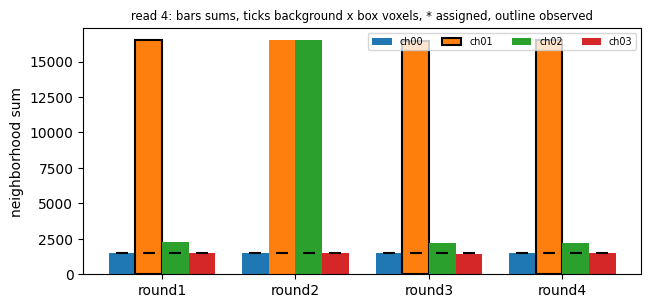

In [30]:
from starfinder.barcode import explain_read, inspect_read, plot_read

inspected = inspect_read(golden_wta.intensity_result, golden_wta.results, "4", reference=golden_wta.codebook)
print("spot 4:", golden_wta.decoding_result.table.set_index("spot_id").loc["4", ["call_status", "failure_reason"]].tolist())
display(inspected[["round", "channel", "color", "valid", "box_voxels", "sum", "background_sum", "subtracted", "noise",
                   "probability", "qc_probability", "observed_color", "observed"]])
tied = inspected[inspected["round"] == "round2"]
top = tied[tied["sum"] == tied["sum"].max()]
print("round2: observed color", tied.observed_color.unique().tolist(), "; brightest channels", top.channel.tolist(),
      "with sums", top["sum"].tolist(), "and probabilities", top.probability.round(6).tolist())
display(plot_read(golden_wta.intensity_result, golden_wta.results, "4", reference=golden_wta.codebook))

`summarize_reads` on the golden reads of both decoders gives the status counts of the golden
pins (`PINNED_STATUS` of `test_readout_golden.py`). WTA has 6 assigned, 1 ambiguous (the tie),
1 no_signal (the zero round) and 2 unmatched (spots 6 and 7). The codebook-aware decoder has 8
assigned (it rescues spots 4 and 6), 1 no_signal and 1 unmatched (spot 7).

In [31]:
GOLDEN_PIN_COUNTS = {"wta": {"assigned": 6, "ambiguous": 1, "no_signal": 1, "unmatched": 2},
                     "codebook_aware": {"assigned": 8, "ambiguous": 0, "no_signal": 1, "unmatched": 1}}
golden_aware = golden_fov(WORKSPACE / "golden-aware",
                          replace(GOLDEN_WTA, decoding=CodebookAwareDecoderConfig(diagnostics=True)))
for name, fov in (("wta", golden_wta), ("codebook_aware", golden_aware)):
    summary = summarize_reads(fov.results)
    print(f"{name}: call_status {summary['call_status']}  equal to the golden pins: "
          f"{summary['call_status'] == GOLDEN_PIN_COUNTS[name]}")
    print(f"    failure_reason {summary['failure_reason']}; call_type {summary['call_type']}")
    print(f"    genes {summary['genes']}")
    print(f"    scoring {summary['scoring']}; filtering {summary['filtering']}")
print("summary keys:", list(summary))

wta: call_status {'assigned': 6, 'ambiguous': 1, 'no_signal': 1, 'unmatched': 2}  equal to the golden pins: True
    failure_reason {'not_in_codebook': 2, 'tied_channels': 1, 'zero_signal_round': 1}; call_type {'exact': 6, 'no_call': 4}
    genes {'GeneA': 1, 'GeneB': 1, 'GeneC': 1, 'GeneD': 1, 'GeneG': 1, 'GeneH': 1}
    scoring {'scored': 6, 'no_assignment': 4, 'background_unavailable': 0}; filtering {'total': 10, 'accepted': 6, 'rejected': 4, 'rejection_reasons': {'call_status': 4}}
codebook_aware: call_status {'assigned': 8, 'ambiguous': 0, 'no_signal': 1, 'unmatched': 1}  equal to the golden pins: True
    failure_reason {'no_candidate': 1, 'zero_signal_round': 1}; call_type {'exact': 6, 'no_call': 2, 'rescued_h1': 1, 'rescued_unknown': 1}
    genes {'GeneA': 2, 'GeneB': 1, 'GeneC': 1, 'GeneD': 1, 'GeneE': 1, 'GeneG': 1, 'GeneH': 1}
    scoring {'scored': 8, 'no_assignment': 2, 'background_unavailable': 0}; filtering {'total': 10, 'accepted': 8, 'rejected': 2, 'rejection_reasons':

Golden spot 6 has round 3 at 0.85 × the amplitude in ch02 and the full amplitude in ch03, so WTA
observes `1244`, which is in no codeword. The codebook-aware decoder rescues it to GeneA
(`1234`): one corrected round, with every gate within its limit. `explain_read` lists those
decisions, here through `FOV.results` (decoding, scoring and filtering). The corrected-round
margin is the decisive gate.

In [32]:
explained = explain_read(golden_aware.results, "6", reference=golden_aware.codebook)
with pd.option_context("display.max_colwidth", 72):
    display(explained)
margin = explained.set_index("item").loc["max_corrected_round_margin"]
print(f"corrected-round margin {margin.value:.3f} {margin.relation} limit {margin.limit:.2f}: passed {margin.passed}")
print("\nexplain_read of the crosstalk copy candidate 1 (deduplication and filter rows):")
copy = explain_read(dedup_on.results, "1", reference=dedup_on.codebook)
display(copy[copy.stage.isin(["deduplication", "filtering"])])
print("explain_read of the direct2 read 0:")
display(explain_read(direct.results, "0", reference=direct.dataset.direct_panel))

,step,stage,item,value,limit,relation,passed,detail
0,1,decoding,decoder,NaN,NaN,,<NA>,codebook_aware
1,2,decoding,valid_rounds,4.000000,4.00,==,True,"every round must be valid, else unmatched with invalid_measurement"
2,3,decoding,zero_signal_rounds,0.000000,0.00,==,True,a round summing to 0 in every channel gives no_signal with zero_sign...
3,4,decoding,observed_color_sequence,NaN,NaN,,<NA>,1244
4,5,decoding,exact_match,NaN,NaN,,False,not in the codebook
5,6,decoding,candidate,1.693950,NaN,,<NA>,"rank 0: 1234 gene GeneA entry CGACC, geomean probability 0.654759"
6,7,decoding,max_hamming,1.000000,1.00,<=,True,
7,8,decoding,max_corrected_round_margin,0.067974,0.20,<=,True,
8,9,decoding,min_score_delta,inf,0.25,>=,True,
9,10,decoding,max_correction_penalty,0.149456,1.50,<=,True,


corrected-round margin 0.068 <= limit 0.20: passed True

explain_read of the crosstalk copy candidate 1 (deduplication and filter rows):


,step,stage,item,value,limit,relation,passed,detail
11,12,deduplication,group,NaN,NaN,,<NA>,group 0 (same_sequence_within_distance)
12,13,deduplication,representative,NaN,NaN,,False,duplicate of 0
13,14,filtering,call_status,NaN,NaN,,True,assigned in assigned
14,15,filtering,duplicate,NaN,NaN,,False,exclude_duplicates=True
15,16,filtering,accepted,NaN,NaN,,False,duplicate


explain_read of the direct2 read 0:


,step,stage,item,value,limit,relation,passed,detail
0,1,assignment,decoder,NaN,NaN,,<NA>,direct
1,2,assignment,panel,NaN,NaN,,True,round1/ch00 -> Gfap
2,3,assignment,own_round_valid,NaN,NaN,,True,"the own round must be valid, else invalid_measurement"
3,4,assignment,own_channel_rank,1.000000,NaN,,<NA>,1 = brightest in its round
4,5,assignment,own_channel_fraction,0.485087,NaN,,<NA>,
5,6,assignment,call,NaN,NaN,,True,assigned direct -> Gfap (entry round1/ch00)
6,7,scoring,qc_score,0.001463,NaN,,<NA>,"lower ranks as more reliable; a ranking, not a probability"
7,8,scoring,qc_ambiguity_max,0.001464,NaN,,<NA>,
8,9,scoring,qc_signal_to_background,1.821333,NaN,,<NA>,
9,10,scoring,qc_rounds,1.000000,NaN,,<NA>,


## 12. Checks and limits

**How the module is checked.**

* **The golden test** (`test/test_readout_golden.py`, W-279) pins with SHA-256 digests the
  extraction tensor, both decoders' tables, the filter tables and the files `FOV.run` writes, on
  the golden fixture. The §2.8 work kept every earlier digest of the tables computed without the
  new columns, and pinned the extended tables apart.
* **The worked examples** (`test/test_readout_examples.py`) follow section 2 step by step.
* **The engineering validation** (checks R1 to R19 of
  [docs/readout-algorithms.md](../../docs/readout-algorithms.md), "Engineering validation design"
  and "Implemented checks (W-296)") runs on known-answer fixtures. Its tolerances were fixed
  before the run, and each either cites a W-278 row or is marked provisional. Hand-built fixtures
  run with seeds 100 to 102, and the W-278-derived checks run on the held-out scenes, seeds 103 to
  105. The calibrated-scene checks R8, R10, R12 and R14 are in the extended tier
  (`-m extended`). The validation is engineering only: it compares no methods and sets no cutoff
  or default.

The cell reads the check table from the page: each check with its fixture, test module and
tolerance source.

In [33]:
def markdown_table(text, heading):
    # The first Markdown table after heading, as a DataFrame of its cells.
    lines = text[text.index(heading):].splitlines()
    start = next(i for i, line in enumerate(lines) if line.startswith("| #"))
    rows = []
    for line in lines[start:]:
        if not line.startswith("|"):
            break
        rows.append([cell.strip() for cell in line.strip("|").split(" | ")])
    return pd.DataFrame(rows[2:], columns=rows[0])


algorithms = (REPOSITORY / "docs" / "readout-algorithms.md").read_text()
design = markdown_table(algorithms, "Checks:")
implemented = markdown_table(algorithms, "### Implemented checks (W-296)")
checks = design[["#", "Check", "Fixture"]].merge(implemented[["#", "Module and tests", "Tolerance"]], on="#")
checks["Module and tests"] = checks["Module and tests"].str.replace("`", "").str.split(",").str[0]
checks["Fixture"] = checks["Fixture"].str.replace("`", "")
checks["Check"] = checks["Check"].str.replace("`", "")
with pd.option_context("display.max_colwidth", 48):
    display(checks)

,#,Check,Fixture,Module and tests,Tolerance
0,R1,Encodings,"1,000 random 6- to 11-base barcodes per seed...",test_readout_encodings.py,exact (provisional)
1,R2,One and two segments,worked example 2; every valid split_index of...,test_readout_layout.py,exact (provisional)
2,R3,one_base decoding,one_base,test_readout_validation.py,exact (provisional)
3,R4,Entries sharing a gene,entries,test_readout_entries.py,exact (provisional)
4,R5,Required rounds and acquisition-local failures,"dropout, both decoders",test_readout_validation.py,exact (provisional)
5,R6,Multiplexed regression,golden; cal seed 103,test_readout_validation.py,equal (provisional)
6,R7,"Direct assignment, known answer",direct2,test_readout_direct.py,exact (provisional)
7,R8,Direct assignment on calibrated scenes (exte...,cal_direct,test_readout_validation.py,above (provisional)
8,R9,Background analytic,"bg_const, bg_neighbor",test_readout_background.py,exact (provisional)
9,R10,Background on calibrated scenes (extended),"cal, dense, at truth positions",test_readout_background.py,W-278 `estimators.csv`


**Known limits** (from W-278 and the pages; [docs/readout-algorithms.md](../../docs/readout-algorithms.md),
"Limitations"):

* the evidence is synthetic only: one 8×64×64 uint8 field of view per seed, with about 19 % of
  the voxels clipped at 0. There is no real data and no E03 evidence;
* every score is a ranking, none is calibrated, and there is no cutoff and no default filter. The
  held-out scenes have few incorrect calls (46 exact and 12 rescued), so per-condition values are
  reported, not gated, and no score separates unmatched detections from correct calls;
* the local ring is not masked for neighbours, tracks the realized background, and its MAD
  underestimates the analytic noise by about 12 % on clipped uint8 data;
* the held-out scenes hold no detectable crosstalk copy, so missed duplicates on calibrated
  scenes are unmeasured. The grouping, the representative and the conflict rule are provisional,
  and d = 1 against d = 2 is an open choice: on the W-218 case d = 1 misses 9 of 22 copies;
* the pipeline settings are fixed (detection at 5 MAD, box (1, 2, 2), matching at 3 voxels),
  and extraction cost was measured on `medium` only;
* `CodebookAwareDecoderConfig` keeps `allow_rescue=True` in Python while the workflow adapter
  turns rescue off. Whether the config itself should default to off is open.

**Size and cost of this notebook.** The bound is 32×64×64 voxels, four channels and four rounds.
The next cell checks it per axis, against two sets of arrays with two or more axes:

* every array that the notebook's own code allocates, as recorded by `note` and `keep`. That
  covers the noise fields, coordinate grids, Gaussian spots, float and uint16 round images,
  projections, candidate positions, and the sums and mask of `clean_read` (4 rounds). Any
  temporary array inside these expressions has the shape of one recorded array;
* every array still reachable from the notebook's variables at this point: the round images
  held by the FOVs and the scene, the scene's per-amplicon signals, the extraction results' sums,
  masks, background and noise, and the decoders' channel probabilities.
  It walks the FOVs, datasets, scenes and results that the stages built.

Each array has named axes. `z`, `y` and `x` are bounded by 32, 64 and 64, and `channel` and
`round` by 4; `spot` (candidates), `amplicon` and `zyx` (the three coordinates) are not bounded. An array
the cell cannot name the axes of fails the check. One-dimensional per-candidate or per-read
vectors carry no voxel, channel or round axis and are left out. The cell also checks the number
of rounds of every fixture and of every round-image mapping. The codebooks of examples 1 and 2
(5 and 9 rounds) are tables of strings, not arrays.

The cell then prints the wall-clock time of the slower steps, measured by `timed` at one thread
on this host. These times vary between runs and are indicative only. They are the only printed
numbers that do.

In [34]:
from dataclasses import is_dataclass

BOUND = {"z": 32, "y": 64, "x": 64, "channel": 4, "round": 4}
FIELD_AXES = {"values": ("spot", "channel", "round"), "background": ("spot", "channel", "round"),
              "noise": ("spot", "channel", "round"), "valid": ("spot", "round"), "box_voxels": ("spot", "round"),
              "background_voxels": ("spot", "round"), "image_background": ("channel", "round"),
              "image_noise": ("channel", "round"), "probabilities": ("spot", "channel", "round"),
              "intended": ("amplicon", "channel", "round"), "pre_mix": ("amplicon", "channel", "round"),
              "realized": ("amplicon", "channel", "round")}
IMAGE_MAPPINGS = ("images", "rounds")


def noted(array):
    ref = NOTED.get(id(array))
    return ref is not None and ref() is array


def retained(obj, field, seen, found, mappings):
    # Every array of two or more axes reachable from obj and not recorded by note, with the axes its field gives.
    if id(obj) in seen:
        return
    seen.add(id(obj))
    if isinstance(obj, np.ndarray):
        if obj.ndim >= 2 and obj.dtype != object and not noted(obj):
            axes = ("z", "y", "x", "channel") if field in IMAGE_MAPPINGS else FIELD_AXES.get(field)
            found.append((field, axes, obj.shape))
    elif isinstance(obj, (dict, MappingProxyType)):
        if field in IMAGE_MAPPINGS and obj and all(isinstance(v, np.ndarray) for v in obj.values()):
            mappings.append((field, len(obj)))
        for key, value in obj.items():
            child = field if field in IMAGE_MAPPINGS or not isinstance(key, str) else key
            retained(value, child, seen, found, mappings)
    elif isinstance(obj, (list, tuple)):
        for value in obj:
            retained(value, field, seen, found, mappings)
    elif type(obj).__module__.startswith("starfinder"):
        members = ({f.name: getattr(obj, f.name) for f in fields(obj)} if is_dataclass(obj) else vars(obj))
        for name, value in members.items():
            retained(value, name, seen, found, mappings)


found, mappings, seen = [], [], set()
for name, value in list(globals().items()):
    if not name.startswith("_"):
        retained(value, name, seen, found, mappings)


def within(axes, shape):
    return axes is not None and all(n <= BOUND.get(a, n) for a, n in zip(axes, shape))


rows = [dict(source="allocated by the notebook", array=name, axes=" x ".join(axes),
             shapes=", ".join(str(s) for s in sorted(shapes)), within_bound=all(within(axes, s) for s in shapes))
        for (name, axes), shapes in ARRAYS.items()]
retained_rows = {}
for field, axes, shape in found:
    retained_rows.setdefault((field, axes), set()).add(shape)
rows += [dict(source="retained in results, FOVs and scenes", array=field,
              axes=" x ".join(axes) if axes else "unnamed", shapes=", ".join(str(s) for s in sorted(shapes)),
              within_bound=all(within(axes, s) for s in shapes))
         for (field, axes), shapes in sorted(retained_rows.items(), key=lambda item: item[0][0])]
audit = pd.DataFrame(rows)
with pd.option_context("display.max_colwidth", 120):
    display(audit)
print("rounds per fixture:", ROUND_COUNTS, " largest round-image mapping:", max(n for _, n in mappings), "rounds")
print("every array within 32x64x64 voxels, 4 channels and 4 rounds:", bool(audit.within_bound.all()),
      " unnamed arrays:", int((audit["axes"] == "unnamed").sum()),
      " every fixture and mapping within 4 rounds:",
      max(ROUND_COUNTS.values()) <= 4 and max(n for _, n in mappings) <= 4)
print("\nwall-clock time of the slower steps (one thread, this host; indicative, varies between runs):")
for label, seconds in TIMINGS.items():
    print(f"  {seconds:6.2f} s  {label}")

,source,array,axes,shapes,within_bound
0,allocated by the notebook,clean_read sums,spot x channel x round,"(1, 4, 4)",True
1,allocated by the notebook,clean_read valid,spot x round,"(1, 4)",True
2,allocated by the notebook,direct2 grid,z x y x x,"(6, 24, 24)",True
3,allocated by the notebook,direct2 float image,z x y x x x channel,"(6, 24, 24, 4)",True
4,allocated by the notebook,direct2 spot,z x y x x,"(6, 24, 24)",True
5,allocated by the notebook,direct2 round image,z x y x x x channel,"(6, 24, 24, 4)",True
6,allocated by the notebook,cal round image,z x y x x x channel,"(8, 64, 64, 4)",True
7,allocated by the notebook,cal candidate positions,spot x zyx,"(74, 3)",True
8,allocated by the notebook,cal round 1 projection,y x x,"(64, 64)",True
9,allocated by the notebook,golden float image,z x y x x x channel,"(12, 48, 48, 4)",True


rounds per fixture: {'direct2': 2, 'cal': 4, 'golden': 4, 'crosstalk': 4}  largest round-image mapping: 4 rounds
every array within 32x64x64 voxels, 4 channels and 4 rounds: True  unnamed arrays: 0  every fixture and mapping within 4 rounds: True

wall-clock time of the slower steps (one thread, this host; indicative, varies between runs):
    0.26 s  generate the cal scene (combined, seed 103, 8x64x64x4, 4 rounds)
    0.09 s  FOV.run on cal, first run
    0.09 s  FOV.run on cal, second run
    0.47 s  FOV.run on crosstalk, deduplication on and off
    0.18 s  FOV.run on golden with CSV checkpoints


## 13. Clean up

The notebook wrote only inside its temporary workspace: codebook and panel files, dataset
directories, and the checkpoints and diagnostics of section 10. The last cell reports what
it wrote and removes the workspace.

In [35]:
written_files = [path for path in WORKSPACE.rglob("*") if path.is_file()]
print(f"{len(written_files)} files, {sum(p.stat().st_size for p in written_files) / 2**10:.0f} KiB written, all under",
      sorted({p.relative_to(WORKSPACE).parts[0] for p in written_files}))
_workspace.cleanup()
print("workspace removed:", not WORKSPACE.exists())

24 files, 29 KiB written, all under ['crosstalk-off', 'crosstalk-on', 'direct-dedup', 'direct-no-sst', 'direct-wta', 'direct2', 'encoding-table-one-base.csv', 'encoding-table.csv', 'example1.csv', 'example2.csv', 'example3.csv', 'example4', 'golden-aware', 'golden-checkpoints', 'golden-extraction', 'golden-run', 'golden-wta', 'invalid-panel.csv', 'wrong-end.csv']
workspace removed: True
